# Active Learning NEP

In [1]:
import os
import numpy as np
import copy as cp
import json
from ase.io import read, write
from ase.visualize import view
#import calorine
from calorine.nep import setup_training, get_descriptors
import phonopy
from hiphive.structure_generation import generate_phonon_rattled_structures
import matplotlib.pyplot as plt
from src.latexfig import LatexFigure
from src.phononASE import phonopy_to_ase
from src.activeNEP import ActiveLearningNEP

/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
structures_add = read('results/ALnep/iteration_2/train.xyz', index=':')

In [9]:
def split_structures_by_chemical_formula(structures):
    #labels = set()
    struct_dict = {}
    for atoms in structures:
        label = atoms.get_chemical_formula()
        #labels.add(label)
        if label not in struct_dict:
            struct_dict[label] = []
        struct_dict[label].append(atoms)
    return struct_dict

In [13]:
struct_add_dict = split_structures_by_chemical_formula(structures_add)

In [14]:
train_data_dict = split_structures_by_chemical_formula(NEP.train_data)

In [21]:
full_list = []

In [22]:
for label in struct_add_dict.keys():
    full_list.extend([struct_add_dict[label][0]])
    full_list.extend(train_data_dict[label])

In [26]:
NEP.run_dir

'results/ALnep3'

In [27]:
write(os.path.join(NEP.run_dir, f"train.xyz"), full_list)

In [12]:
struct_add_dict.keys()

dict_keys(['Ba8O24Ti8', 'Ba8O32Ti12', 'Ba4O20Ti8'])

In [ ]:
view(read(f'results/ALnep/iteration_1/md/temp/run_002/dump.xyz', index=':'))

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

Traceback (most recent call last):
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 34, in <module>
    main()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 30, in main
    plt.show()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/matplotlib/pyplot.py", line 613, in show
    return _get_backend_mod().show(*args, **kwargs)
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/matplotlib_inline/backend_inline.py", line 90, in show
    display(
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/IPython/core/display_functions.py", line 265, in

In [ ]:
view(read('results/ALnep/iteration_2/md/Ba8O32Ti12/600K/dump.xyz', index=':'))

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

Traceback (most recent call last):
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 34, in <module>
    main()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 30, in main
    plt.show()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/matplotlib/pyplot.py", line 613, in show
    return _get_backend_mod().show(*args, **kwargs)
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/matplotlib_inline/backend_inline.py", line 90, in show
    display(
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/IPython/core/display_functions.py", line 265, in

In the following, we go through each step of the active learning scheme.

In [2]:
NEP = ActiveLearningNEP('results/ALnep3')

Current iteration: 3


Loaded 128 training structures and 84 test structures
All structures have calculator results.
No existing NEP model found.
No existing active set inverse (.asi) or structures (.xyz) found.


In [28]:
# List all folders in md_dir
md_dir = os.path.join(NEP.iter_dir, "md")
md_folders = [d for d in os.listdir(md_dir) if os.path.isdir(os.path.join(md_dir, d))]
# Loop over chemical formula folders, then temperature folders to run GPUMD simulations
for label in md_folders:
    label_dir = os.path.join(md_dir, label)
    temp_folders = [d for d in os.listdir(label_dir) if os.path.isdir(os.path.join(label_dir, d))]
    for temp in temp_folders:
        temp_dir = os.path.join(label_dir, temp)
        # List files in temp_dir to check for .out files
        if any(file.endswith(".out") for file in os.listdir(temp_dir)):
            print(f"GPUMD simulation already run for {temp_dir}. Skipping...")
            continue
        else:
            print(f"Running GPUMD simulation for {temp_dir}...")

GPUMD simulation already run for results/ALnep/iteration_2/md/Ba8O24Ti8/exploration. Skipping...
GPUMD simulation already run for results/ALnep/iteration_2/md/Ba8O24Ti8/100K. Skipping...
GPUMD simulation already run for results/ALnep/iteration_2/md/Ba8O24Ti8/200K. Skipping...
GPUMD simulation already run for results/ALnep/iteration_2/md/Ba8O24Ti8/300K. Skipping...
GPUMD simulation already run for results/ALnep/iteration_2/md/Ba8O24Ti8/400K. Skipping...
GPUMD simulation already run for results/ALnep/iteration_2/md/Ba8O24Ti8/500K. Skipping...
GPUMD simulation already run for results/ALnep/iteration_2/md/Ba8O24Ti8/600K. Skipping...
GPUMD simulation already run for results/ALnep/iteration_2/md/Ba8O32Ti12/exploration. Skipping...
GPUMD simulation already run for results/ALnep/iteration_2/md/Ba8O32Ti12/100K. Skipping...
GPUMD simulation already run for results/ALnep/iteration_2/md/Ba8O32Ti12/200K. Skipping...
GPUMD simulation already run for results/ALnep/iteration_2/md/Ba8O32Ti12/300K. Skip

In [6]:
from src.calculators import copy_calc_results

In [6]:
from ase.build import sort

In [18]:
# Sort atoms by alphabetical order of chemical symbols to ensure consistency in descriptor calculation and active set selection

train_data = []
test_data = []
for atoms in NEP.train_data:
    try:
        sorted_atoms = copy_calc_results(atoms, sort=True)
    except RuntimeError:
        sorted_atoms = sort(atoms)
    train_data.append(sorted_atoms)

for atoms in NEP.test_data:
    try:
        sorted_atoms = copy_calc_results(atoms, sort=True)
    except RuntimeError:
        sorted_atoms = sort(atoms)
    test_data.append(sorted_atoms)


In [3]:
def shift_energies(data):
    # Attempt to read energies from energies.json, which should have been generated by the DFT calculations
    try:
        with open(os.path.join(NEP.run_dir, 'energies.json'), 'r') as f:
            energies = json.load(f)

    except FileNotFoundError:
        energies = None
        print("Atomic energies file (energies.json) not found in directory.")
        print("It is highly recommended to have the atomic energies of the constituent elements for better NEP training.", flush=True)

    # Shift the energies of the structures by the sum of the energies of the constituent atoms, if energies are available
    for atoms in data:
        elements = atoms.get_chemical_symbols()
        if energies is not None:
            atoms.calc.results['energy'] -= sum(energies[element] for element in elements)

In [ ]:
#shift_energies(NEP.test_data)

In [ ]:
#write(os.path.join(NEP.run_dir, f"train.xyz"), NEP.train_data)
#write(os.path.join(NEP.run_dir, f"test.xyz"), NEP.test_data)

In [12]:
structures = read(os.path.join(NEP.iter_dir, f"train.xyz"), index=':')

In [14]:
for atoms in structures:
    try:
        del atoms.arrays['descriptor']
    except KeyError:
        pass
    try:
        del atoms.arrays['gamma']
    except KeyError:
        pass


In [15]:
write(os.path.join(NEP.iter_dir, f"train.xyz"), structures)

## Active Learning Loop

### 0. Data generation

If the dataset has not yet been generated, it is done by phonon ratteling & strain.

This requires .yaml files for constructing force constants matrix and obtaining phonon modes.

In [37]:
# Prepare dataset by phonon ratteling
NEP.prepare_dataset()

Existing data found. Data preperation skipped.
To overwrite existing data, set overwrite=True.


### 1. DFT labeling

Now DFT is performed on all dataset structures in train.xyz and test.xyz

In [38]:
# Run DFT calculations on the generated structures
#NEP.run_DFT()      # run on HPC CPU node (sylg.fysik.dtu.dk)

### 2. Training NEP

The structures in train.xyz and test.xyz are copied to the iteration folder.

During this process, energies are shifted by atomic energies and atoms ordered alphabetically.

Furthermore, the necesassy nep.in file is created based on the parameters bellow.

In [3]:
# Define parameters for training the NEP model
params = dict(cutoff=[8, 4],
              neuron=30,
              generation=100000,
              batch=1000000)
NEP.setup_nep(**params)
#NEP.train_nep()    # run on HPC GPU node (surt.fysik.dtu.dk or sara.fysik.dtu.dk)

In [5]:
view(NEP.train_data)

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/images.py:97: UserWarning: Not all images have the same boundary conditions!
  warnings.warn('Not all images have the same boundary conditions!')
Traceback (most recent call last):
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 34, in <module>
    main()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 30, in main
    plt.show()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/matplotlib/pyplot.py", line 613, in show
    return _get_backend_mod().show(*args, **kwargs)
  File "/home/tbrav/miniconda3/envs/siesta-env

We can inspect training to see, how the loss and RMSE values change with generation.

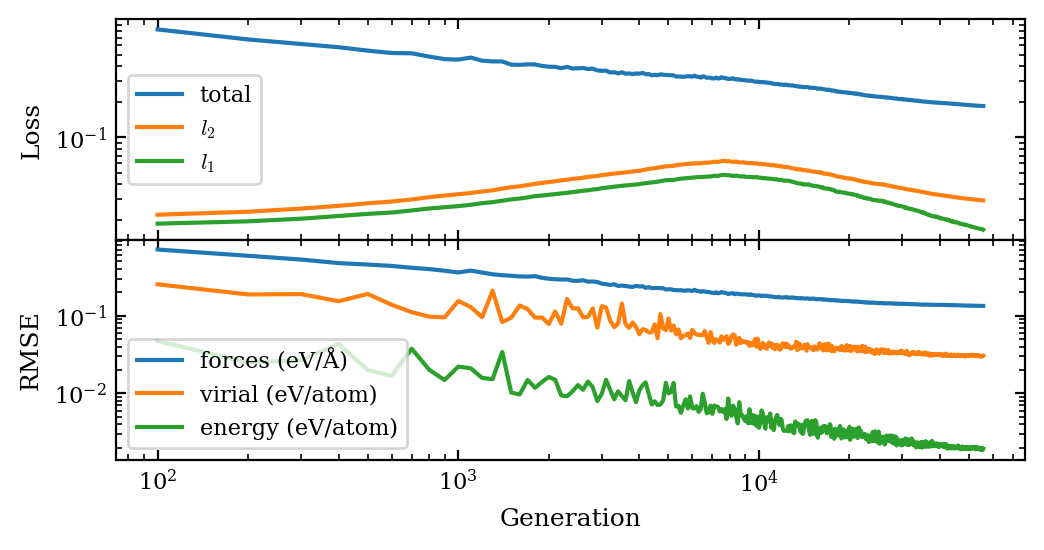

In [16]:
fig = NEP.plot_loss()
#fig.savefig('figures/Loss_and_RMSE.pdf', bbox_inches='tight')

We can also inspect predicted vs target values for energy, force, viral and stress.

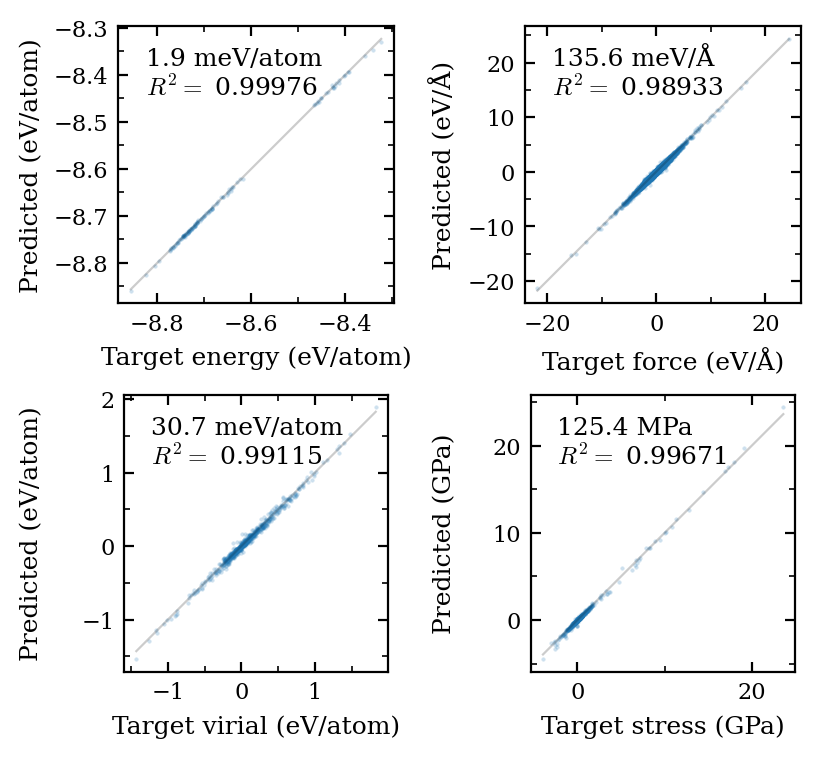

In [15]:
fig = NEP.plot_parity()
#fig.savefig('figures/parity.pdf', bbox_inches='tight')

### 3. Build active set

With the NEP model trained, we need to build an active set to calculate extrapolation grades.

In [3]:
# Build Active Set (.asi) with MaxVol
NEP.build_active_set()

Building active set...
Calculating descriptors for 104 structures...


100%|██████████| 104/104 [00:04<00:00, 21.26it/s]


Building active set for Ba...
Maxvol Speed: 14576 iters/s
Building active set for O...
Maxvol Speed: 4111 iters/s
Building active set for Ti...
Maxvol Speed: 10495 iters/s
Active set inverse saved to results/ALnep3/iteration_2/active_set.asi
Active set structure saved to results/ALnep3/iteration_2/active_set.xyz


In [ ]:
#view(NEP.active_set_struct)

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/images.py:97: UserWarning: Not all images have the same boundary conditions!
  warnings.warn('Not all images have the same boundary conditions!')
Traceback (most recent call last):
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 34, in <module>
    main()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 30, in main
    plt.show()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/matplotlib/pyplot.py", line 613, in show
    return _get_backend_mod().show(*args, **kwargs)
  File "/home/tbrav/miniconda3/envs/siesta-env

Now that we have the active set, we can calculate the extrapolation grade of all atoms.

In [11]:
NEP.assign_gamma(NEP.train_data)

Calculating descriptors for 776 structures...


100%|██████████| 776/776 [00:17<00:00, 44.87it/s]


Gamma range: 0.1956 - 1.0


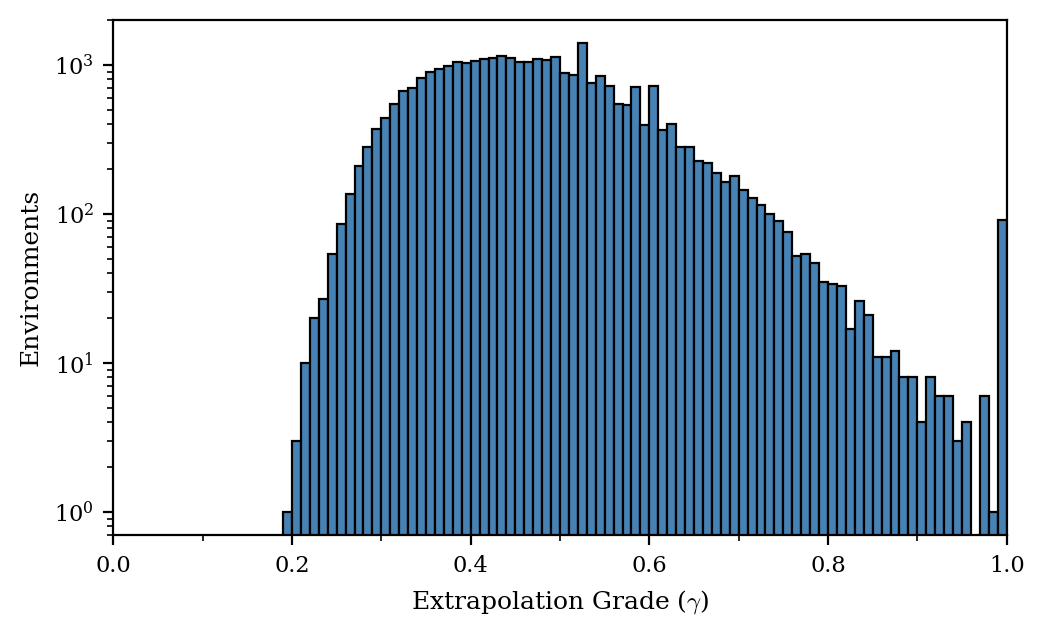

In [ ]:
fig = NEP.plot_gamma_model(NEP.train_data, per_struct=False)

As expected, all structures have extrapolation bellow 1.

We now investigate strained structures

In [48]:
# Apply some strain to the active set structures and re-assign gamma to see how the extrapolation grade changes
NEP.build_active_set()
for atoms in NEP.active_set_struct:
    NEP._strain_structure(atoms, 5)


Existing active set inverse (.asi) and structures (.xyz) found. Loading...


Calculating descriptors for 68 structures...


100%|██████████| 68/68 [00:01<00:00, 49.76it/s]


Gamma range: 0.23154 - 1.85368


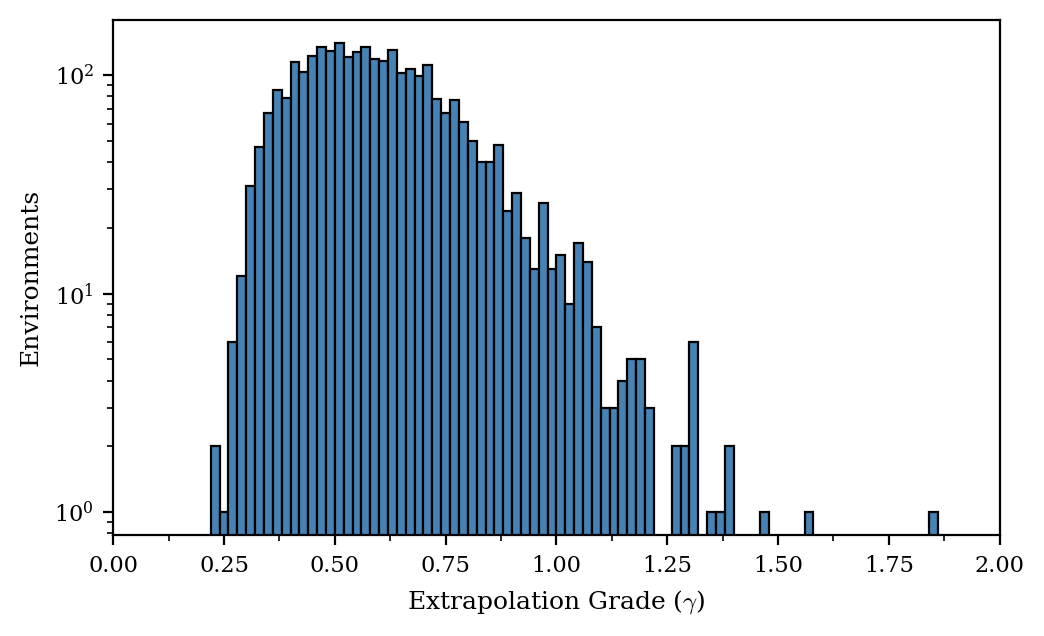

In [49]:
NEP.assign_gamma(NEP.active_set_struct)
plot_gamma_model(NEP.active_set_struct, per_struct=False)

We can now test how resilient the dataset is to larger supercells/systems.

In [ ]:
#sc_structures = [NEP.train_data[i].repeat((2, 2, 1)) for i in range(len(NEP.train_data))]

In [ ]:
NEP.assign_gamma(sc_structures)

All structures already have descriptors calculated.


Gamma range: 0.60647 - 1.74285


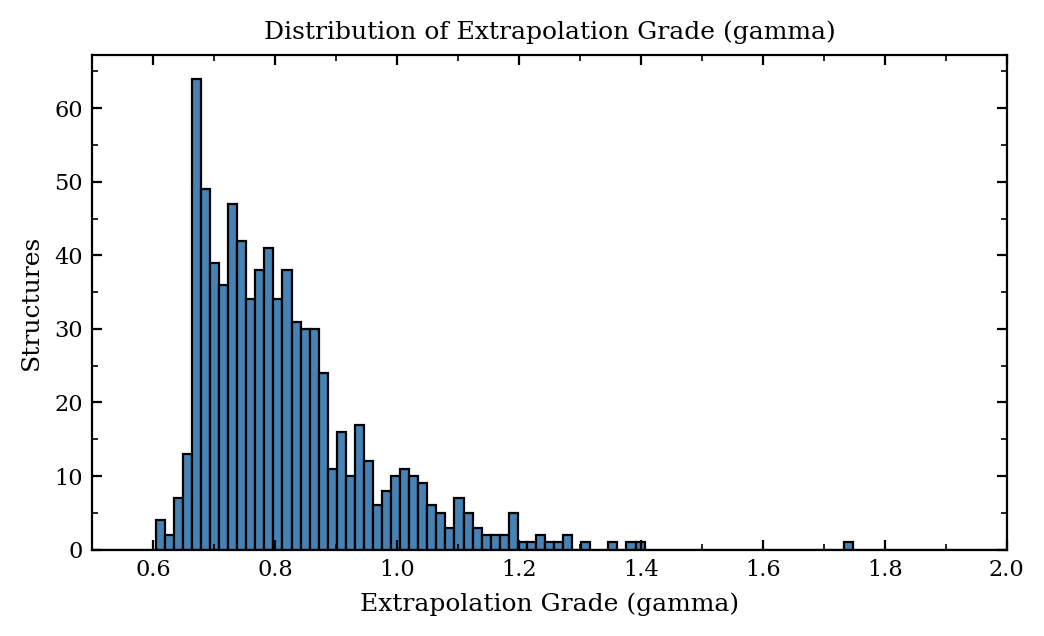

In [ ]:
plot_gamma_model(sc_structures)

These are all bellow 2, so considered a safe extrapolation.

What if we try to make thicker slabs than the model has been trained on?

In [ ]:
from src.structure import Perovskite
slab_structures = [Perovskite('BaTiO3', bulk=False, dslab=(1.5+i)).atoms.repeat((2, 2, 1)) for i in range(2, 20)]

In [ ]:
slab_descriptors = NEP._calculate_descriptors(slab_structures)

Computed descriptor matrix: (4356, 30)


Gamma range: 2.06887 - 2.06887


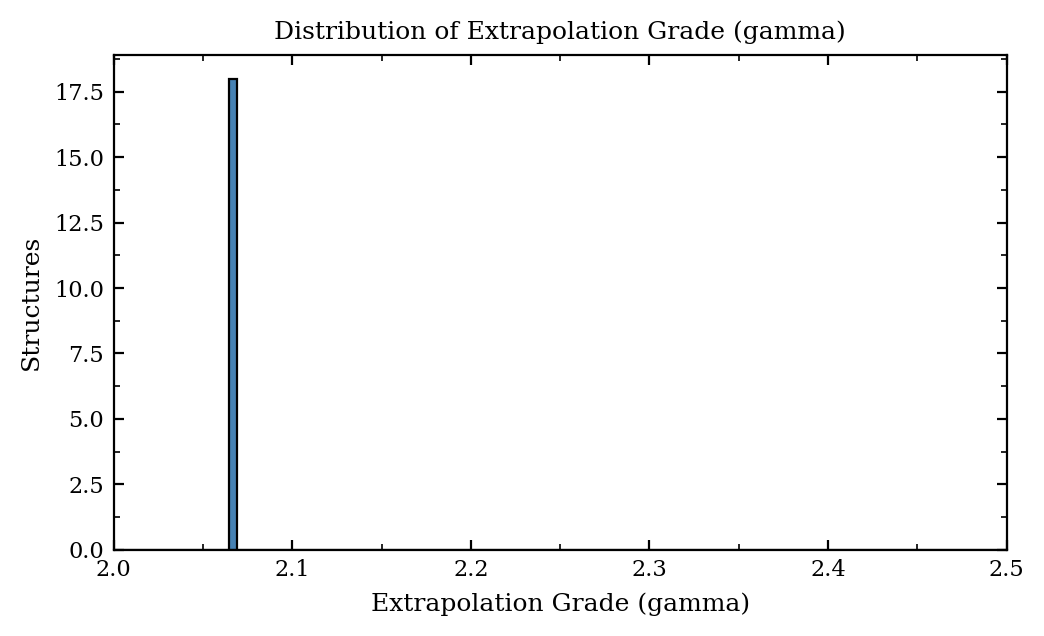

In [ ]:
NEP.assign_gamma(slab_structures, slab_descriptors)
plot_gamma_model(slab_structures)

Does not change at all. Note strain on lattice, should use relaxed slabs for lower gamma.

Now additional phonon ratteling.

In [51]:
import phonopy as ph
from src.phononASE import phonon_to_atoms
phonon = ph.load('results/ALnep/bulk.yaml')

# Produce the force constants
phonon.produce_force_constants()
# Get the force constants matrix
fc = phonon.force_constants

# Convert the phonon object to an ASE Atoms object
atoms = phonon_to_atoms(phonon, cell='super')
rattled_structures = NEP._get_rattled_structures(atoms, fc, 500, 1000)

Acoustic sum rules not enforced, squared frequencies: [0.00482294 0.00485357 0.00488422]
Imaginary modes present


Calculating descriptors for 1000 structures...


100%|██████████| 1000/1000 [00:38<00:00, 25.69it/s]


Gamma range: 0.70159 - 1.93261


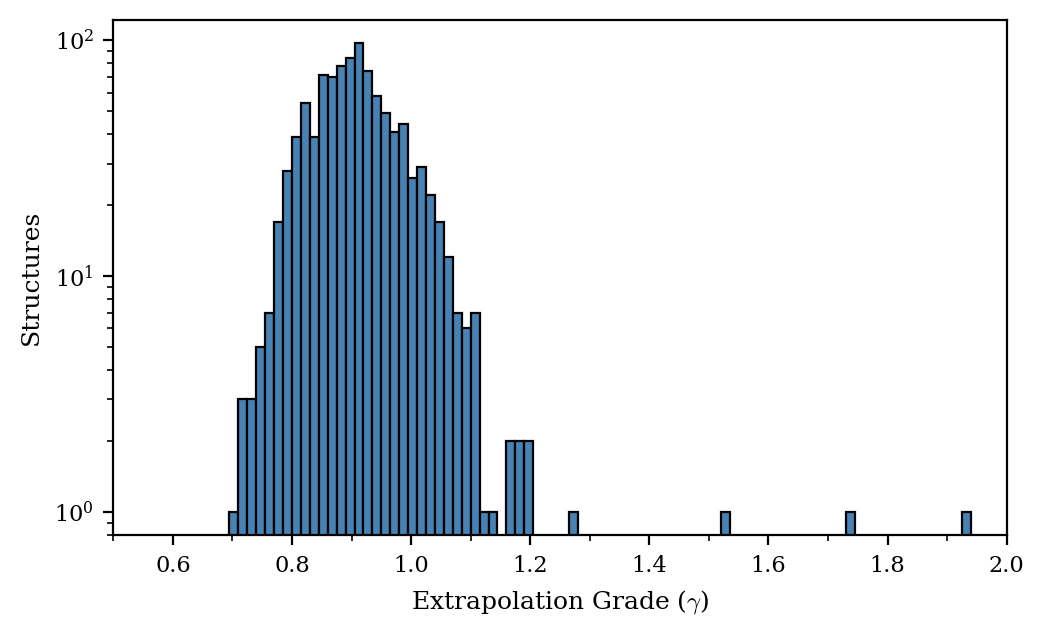

In [52]:
NEP.assign_gamma(rattled_structures)
plot_gamma_model(rattled_structures)

### 4. MD exploration

We now run MD to explore for new configurations that have high extrapolation grade.

In [3]:
# Set up MD exploration
NEP.setup_MD_exploration(dt=1, n_steps=1*1e6, n_dump=2000, Tmax=600)
#NEP.run_MD()       # run on HPC GPU node (surt.fysik.dtu.dk or sara.fysik.dtu.dk)

In [3]:
NEP.collect_MD_structures()

In [14]:
NEP.iter_dir

'results/ALnep3/iteration_2'

In [5]:
md_structures = read(os.path.join(NEP.iter_dir, 'md_exploration/md_structures.xyz'), index=':')

In [6]:
len(md_structures)

6000

In [15]:
view(md_structures)

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/images.py:97: UserWarning: Not all images have the same boundary conditions!
  warnings.warn('Not all images have the same boundary conditions!')
Exception in Tkinter callback
Traceback (most recent call last):
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/tkinter/__init__.py", line 1921, in __call__
    return self.func(*args)
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/ui.py", line 205, in <lambda>
    bind_enter(self.widget, lambda event: self.callback())
TypeError: 'NoneType' object is not callable


In [ ]:
#md_structures = []

#for label in ['Ba4O20Ti8', 'Ba8O24Ti8', 'Ba8O32Ti12']:
#    structures = read(f'results/ALnep3/iteration_1/md_exploration/{label}/600K/dump.xyz', index=':')
    # Downsize and take every 10th structure to reduce the number of structures for DFT calculations
#    write(f'results/ALnep3/iteration_1/md_exploration/{label}/600K/dump.xyz', structures[::10])

In [ ]:
"""
md_structures = []
for label in ['Ba4O20Ti8', 'Ba8O24Ti8', 'Ba8O32Ti12']:
    structures = read(f'results/ALnep3/iteration_1/md_exploration/{label}/600K/dump.xyz', index=':')
    md_structures.extend(structures)
"""

In [8]:
NEP.assign_gamma(md_structures)

Calculating descriptors for 6000 structures...


  0%|          | 0/6000 [00:00<?, ?it/s]

100%|██████████| 6000/6000 [04:57<00:00, 20.20it/s]


In [20]:
test = [struct for struct in md_structures if max(struct.arrays["gamma"]) > 1.001]

In [21]:
len(test)

1059

In [ ]:
view(test)

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/images.py:97: UserWarning: Not all images have the same boundary conditions!
  warnings.warn('Not all images have the same boundary conditions!')


In [80]:
len(test)

1364

In [81]:
view(test)

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/images.py:97: UserWarning: Not all images have the same boundary conditions!
  warnings.warn('Not all images have the same boundary conditions!')
Traceback (most recent call last):
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 34, in <module>
    main()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 30, in main
    plt.show()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/matplotlib/pyplot.py", line 613, in show
    return _get_backend_mod().show(*args, **kwargs)
  File "/home/tbrav/miniconda3/envs/siesta-env

Gamma range: 0.63962 - 2.44609


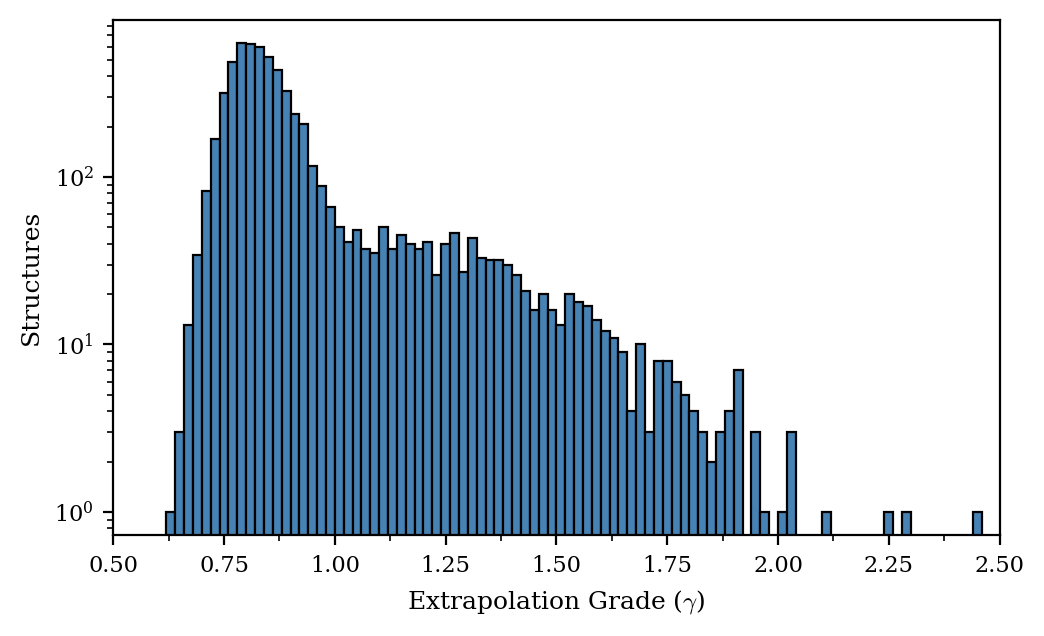

In [12]:
fig = NEP.plot_gamma_model(md_structures, per_struct=True)

In [61]:
# Collect structure from different MD runs
#NEP.collect_MD_structures()
md_structures = []
for temp in ['100K', '200K', '300K', '400K', '500K', '600K']:
    md_structures.extend(read(os.path.join(NEP.iter_dir, f'md_old4/Ba4O20Ti8/{temp}/dump.xyz'), ':'))
#md_structures
#md_test = md_test[-1000:]

In [13]:
md_structures = read(os.path.join(NEP.iter_dir, 'md/md_structures.xyz'), index=':')

In [14]:
from ase.visualize import view
view(md_structures)

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/images.py:97: UserWarning: Not all images have the same boundary conditions!
  warnings.warn('Not all images have the same boundary conditions!')
Traceback (most recent call last):
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 34, in <module>
    main()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 30, in main
    plt.show()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/matplotlib/pyplot.py", line 613, in show
    return _get_backend_mod().show(*args, **kwargs)
  File "/home/tbrav/miniconda3/envs/siesta-env

All structures already have descriptors calculated.
Gamma range: 0.16734 - 1.2903


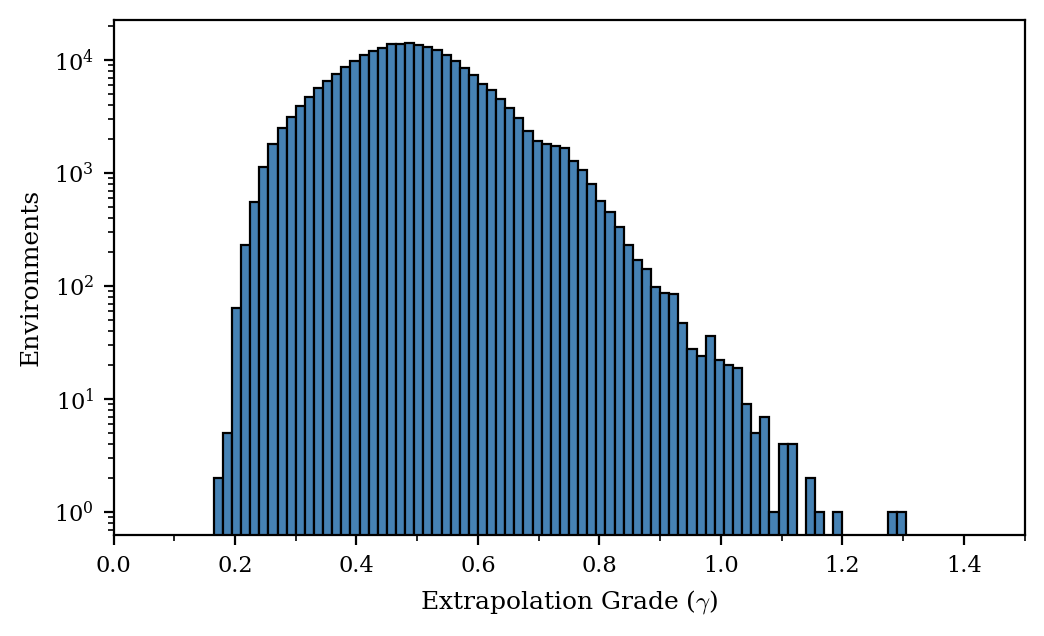

In [9]:
NEP.assign_gamma(md_structures)
plot_gamma_model(md_structures, per_struct=False)

In [ ]:
#from src.structure import wrap_to_reference
def wrap_continuous(traj, ref_atoms):
    wrapped = []

    #prev = ref_atoms.copy()
    #wrapped.append(prev)

    #cell = ref_atoms.get_cell()
    ref_scaled = ref_atoms.get_scaled_positions()

    for atoms in traj:
        new_atoms = atoms.copy()

        scaled = atoms.get_scaled_positions()

        delta = scaled - ref_scaled
        delta -= np.floor(delta + 0.5)  # wrap into [-0.5, 0.5]

        new_scaled = ref_scaled + delta

        new_atoms.set_scaled_positions(new_scaled)

        wrapped.append(new_atoms)

        # update reference
        ref_scaled = new_scaled

    return wrapped

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

### 5. Structure filtering

To not consider all structures obtained from MD, we can calculate extrapolation grade and filter.

All structures containing no atoms/environments with gamma > gamma_th are removed.

In [22]:
#md_structures = read(os.path.join(NEP.iter_dir, 'md/md_structures.xyz'), index=':')

In [23]:
md_structures = read(os.path.join(NEP.iter_dir, 'md_exploration/md_structures.xyz'), index=':')

In [ ]:
view(md_structures)

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

Traceback (most recent call last):
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 34, in <module>
    main()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 30, in main
    plt.show()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/matplotlib/pyplot.py", line 613, in show
    return _get_backend_mod().show(*args, **kwargs)
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/matplotlib_inline/backend_inline.py", line 90, in show
    display(
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/IPython/core/display_functions.py", line 265, in

All structures already have gamma values.
Gamma range: 0.49114 - 2.05674


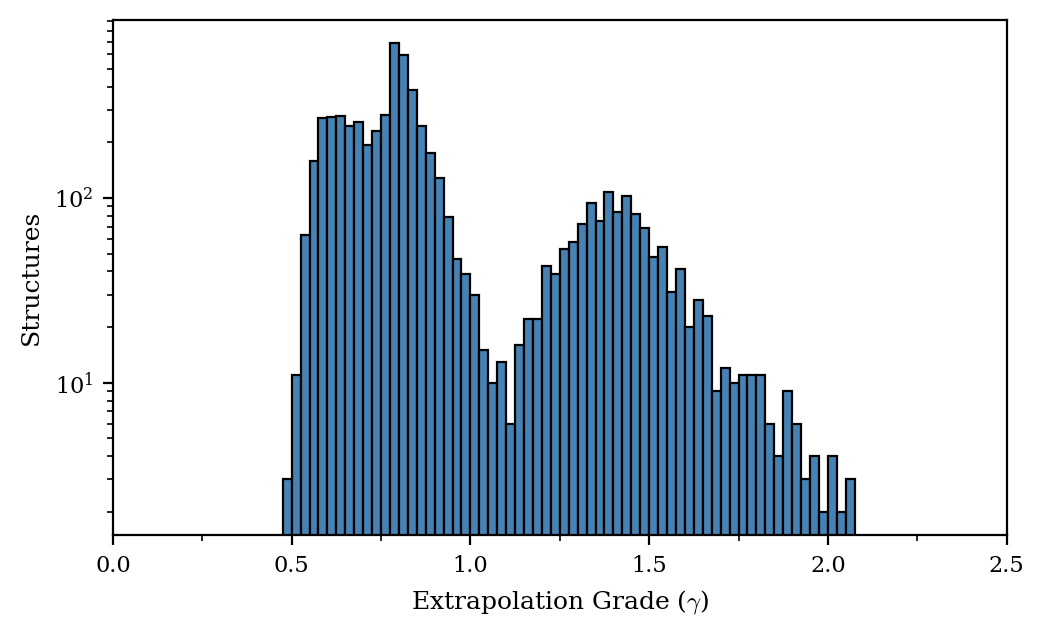

In [8]:
NEP.assign_gamma(md_structures)
fig = NEP.plot_gamma_model(md_structures, per_struct=True)

In [25]:
# Load the collected structures and filter them based on the gamma threshold
#structures = read(os.path.join(NEP.iter_dir, "md/md_structures.xyz"), index=":")
NEP.filter_structures(md_structures, gamma_th=1.001)

Filtering out structures with gamma < 1.001...
Calculating descriptors for structures...
All structures already have gamma values.
Found 1059 structures with gamma > 1.001.


### 6. Diversity selection

Since we do not wish to perform DFT on all high-gamma structures, diversity selection is performed.

This ensures that only structures with atoms contributing with new basis vectors in the active set are included.

By doing this, only the most diverse environments are included.

In [27]:
len(structures)

1059

In [28]:
# Read high gamma structures and select based on diversity (MaxVol)
structures = read(os.path.join(NEP.iter_dir, "large_gamma.xyz"), index=":")
#len(structures)
NEP.select_structures(structures)

Performing diversity selection with MaxVol
All structures already have descriptors calculated.
Building active set for Ba...
Maxvol Speed: 2143 iters/s
Building active set for O...
Maxvol Speed: 308 iters/s
Building active set for Ti...
Maxvol Speed: 929 iters/s
Found 24 filtered structures.


In [29]:
selected_structures = read(os.path.join(NEP.iter_dir, "newdata.xyz"), index=':')

In [30]:
view(selected_structures)

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

In [31]:
len(selected_structures)

24

In [15]:
selected_structures[0]

Atoms(symbols='Ba8O32Ti12', pbc=[True, True, False], cell=[[7.95036605, 0.00277671, 0.0], [0.04704631, 7.66621145, 0.0], [0.0, 0.0, 47.96]])

In [32]:
NEP.update_dataset()

Sucessfully added 24 structures to train.xyz
Total structures in train.xyz: 128


In [85]:
def calculate_dE_dF(structures):
    from calorine.calculators import CPUNEP

    for structure in structures:
        try:
            E_DFT = structure.get_potential_energy()
            F_DFT = structure.get_forces().copy()
        except RuntimeError:
            continue
        calc = CPUNEP(NEP.nep_txt)
        atoms = structure.copy()
        N_atoms = len(atoms)
        atoms.calc = calc
        E_ML = atoms.get_potential_energy()
        F_ML = atoms.get_forces()

        # Calculate energy error per structure
        dE = np.abs(E_DFT - E_ML)
        structure.info["dE"] = dE/N_atoms

        # Calculate the norm of the force error per structure
        dF = np.linalg.norm(F_DFT - F_ML, axis=1)
        structure.arrays["dF"] = dF

        #dFs.append(dF)
        #gammas.append(gamma)


In [86]:
calculate_dE_dF(structures)

In [93]:
def plot_dE_gamma(structures):
    dE = np.array([struct.info["dE"]*1e3 for struct in structures])
    gamma = np.array([max(struct.arrays["gamma"]) for struct in structures])

    lf = LatexFigure()
    fig, axes = lf.create()

    axes[0].scatter(gamma, dE, alpha=0.5, s=10, color='steelblue', lw=0.8)
    # Plot dashed line at gamma = 1
    axes[0].axvline(1, color='k', linestyle='--', lw=0.8)
    axes[0].set_xlabel('$\\gamma$ (per structure)')
    axes[0].set_ylabel('|dE| (meV/atom)')
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    axes[0].set_xlim(1e-1, 1e1)
    plt.show()

In [94]:
def plot_dF_gamma(structures, per_struct=False):

    try:
        if per_struct:
            gammas = np.array([max(structures[i].arrays["gamma"]) for i in range(len(structures))])
            dFs = np.array([max(structures[i].arrays["dF"]) for i in range(len(structures))])
        else:
            gammas = np.array([gamma for struct in structures for gamma in struct.arrays["gamma"]])
            dFs = np.array([dF for struct in structures for dF in struct.arrays["dF"]])
    except Exception:
        print(f"Missing 'gamma' or 'dF' arrays in structures. Make sure to run calculate_dE_dF() first and that the structures have been assigned gamma values.")
        return

    lf = LatexFigure()
    fig, axes = lf.create()

    axes[0].scatter(gammas, dFs, alpha=0.5, s=10, color='steelblue', lw=0.8)
    # Plot dashed line at gamma = 1
    axes[0].axvline(1, color='k', linestyle='--', lw=0.8)
    axes[0].set_xlabel('$\\gamma$ (per structure)' if per_struct else '$\\gamma$ (per atom)')
    axes[0].set_ylabel('|dF| (eV/Å)')
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    axes[0].set_xlim(1e-1, 1e1)
    plt.show()
    #axes[0].set_ylim(1e-10, 1e1)

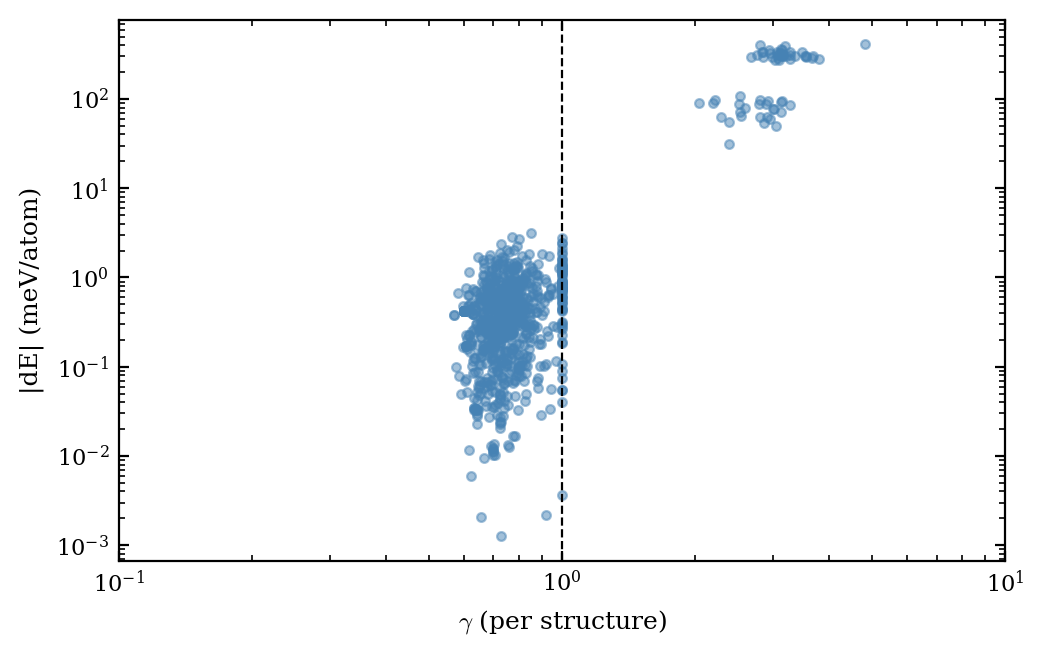

In [95]:
plot_dE_gamma(structures)

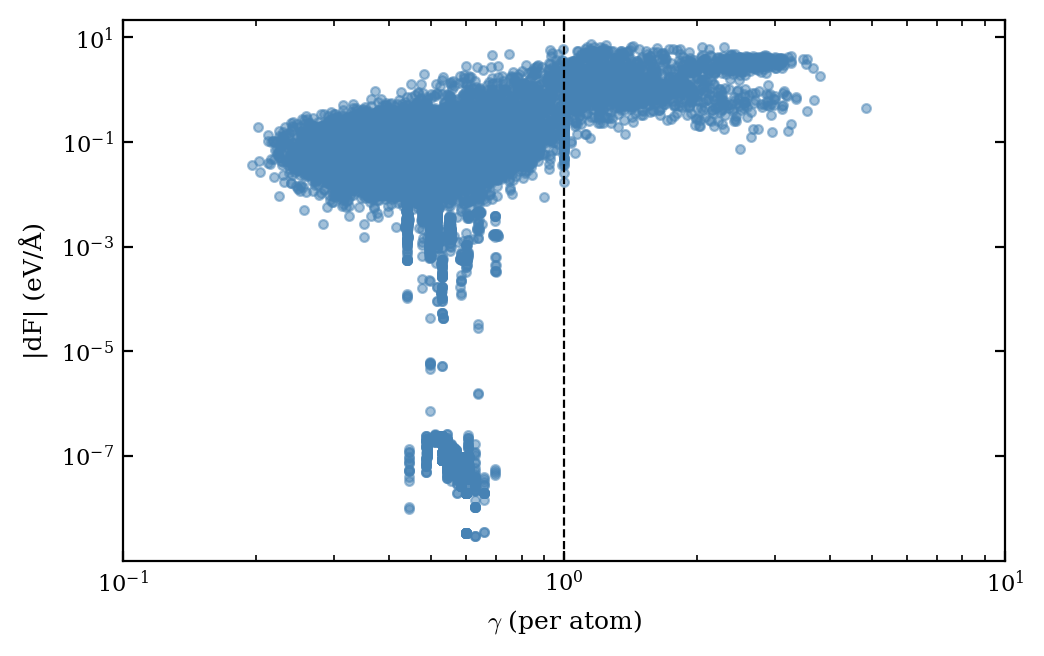

In [96]:
plot_dF_gamma(structures, per_struct=False)

Calculating descriptors for 838 structures...


100%|██████████| 838/838 [00:19<00:00, 43.45it/s]


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (838,) + inhomogeneous part.

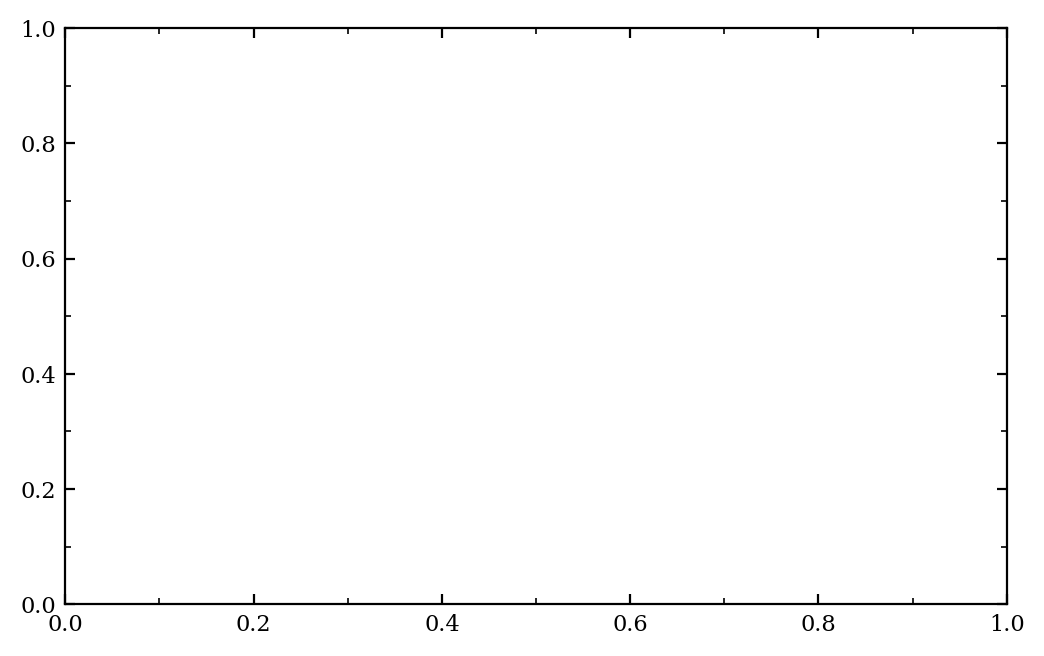

In [12]:
NEP.assign_gamma(NEP.train_data)
plot_dF_gamma(NEP.train_data)

In [ ]:
import phonopy as ph
from src.phononASE import phonon_to_atoms
phonon = ph.load('results/MLtest/BaTiO3.yaml')

# Produce the force constants
phonon.produce_force_constants()
# Get the force constants matrix
fc = phonon.force_constants

# Convert the phonon object to an ASE Atoms object
atoms = phonon_to_atoms(phonon, cell='super')
new_structures = NEP._get_rattled_structures(atoms, fc, 300, 1000)

Acoustic sum rules not enforced, squared frequencies: [0.00482294 0.00485357 0.00488422]
Imaginary modes present


In [ ]:
new_structures = [NEP.train_data[i].repeat((2, 2, 2)) for i in range(len(NEP.train_data))]

In [ ]:
from ase.visualize import view
view(new_structures)

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

In [ ]:
NEP.filter_structures(new_structures, gamma_th=2)

Filtering out structures with gamma < 2...
Calculating descriptors for structures...
Computed descriptor matrix: (40000, 30)
Found 703 structures with gamma > 2.


In [ ]:
filtered_structures = read('results/MLtest/iteration_1/large_gamma.xyz', index=':')

In [ ]:
NEP.select_structures(filtered_structures)

Performing diversity selection with MaxVol
Computed descriptor matrix: (33960, 30)
Performing MaxVol for type 0...
Maxvol Speed: 3150 iters/s
Performing MaxVol for type 1...
Maxvol Speed: 708 iters/s
Performing MaxVol for type 2...
Maxvol Speed: 2800 iters/s
Found 70 filtered structures.


In [ ]:
selected_structures = read('results/MLtest/iteration_1/newdata.xyz', index=':')

In [ ]:
from ase.visualize import view
view(selected_structures[0])

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

In [ ]:
selected_structures[0].arrays["gamma"]

array([7.98459161, 0.64577987, 1.09839168, 0.66486749, 0.64219275,
       0.95533611, 0.5669056 , 0.7393601 , 0.59651215, 0.90349156,
       0.55610104, 0.41381781, 0.82241194, 1.25364715, 0.88207511,
       0.87662537, 0.65588566, 1.05112227, 0.84457924, 1.06276169,
       0.59676655, 1.07429597, 0.62982156, 0.66234556, 0.48279781,
       0.68901255, 0.72202063, 0.39778553, 1.01825688, 0.98255694,
       0.71552915, 0.45275   , 0.53090655, 2.70847324, 0.54794066,
       0.44221814, 0.40284996, 0.57034556, 0.48180711, 0.63234743])

In [ ]:
np.array(selected_structures[0].get_chemical_symbols())

array(['Ba', 'Ba', 'Ba', 'Ba', 'Ba', 'Ba', 'Ba', 'Ba', 'Ti', 'Ti', 'Ti',
       'Ti', 'Ti', 'Ti', 'Ti', 'Ti', 'O', 'O', 'O', 'O', 'O', 'O', 'O',
       'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O',
       'O', 'O', 'O', 'O'], dtype='<U2')

In [ ]:
view(new_structures[0])

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

In [ ]:
view(new_structures)

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/images.py:97: UserWarning: Not all images have the same boundary conditions!
  warnings.warn('Not all images have the same boundary conditions!')


In [ ]:
view(new_structures[0])

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

In [ ]:
import numpy as np
#gamma_model = np.array([max(NEP.train_data[i].arrays["gamma"]) for i in range(len(NEP.train_data))])
#gamma_new_structures = np.array([max(new_structures[i].arrays["gamma"]) for i in range(len(new_structures))])
gamma_filtered_structures = np.array([max(filtered_structures[i].arrays["gamma"]) for i in range(len(filtered_structures))])
gamma_selected_structures = np.array([max(selected_structures[i].arrays["gamma"]) for i in range(len(selected_structures))])
gamma_min = min(gamma_filtered_structures.min(), gamma_selected_structures.min())
gamma_max = max(gamma_filtered_structures.max(), gamma_selected_structures.max())
print(f'Min extrapolation grade across structures: {gamma_min}')
print(f'Max extrapolation grade across structures: {gamma_max}')

Min extrapolation grade across structures: 2.00304034
Max extrapolation grade across structures: 46.54833812


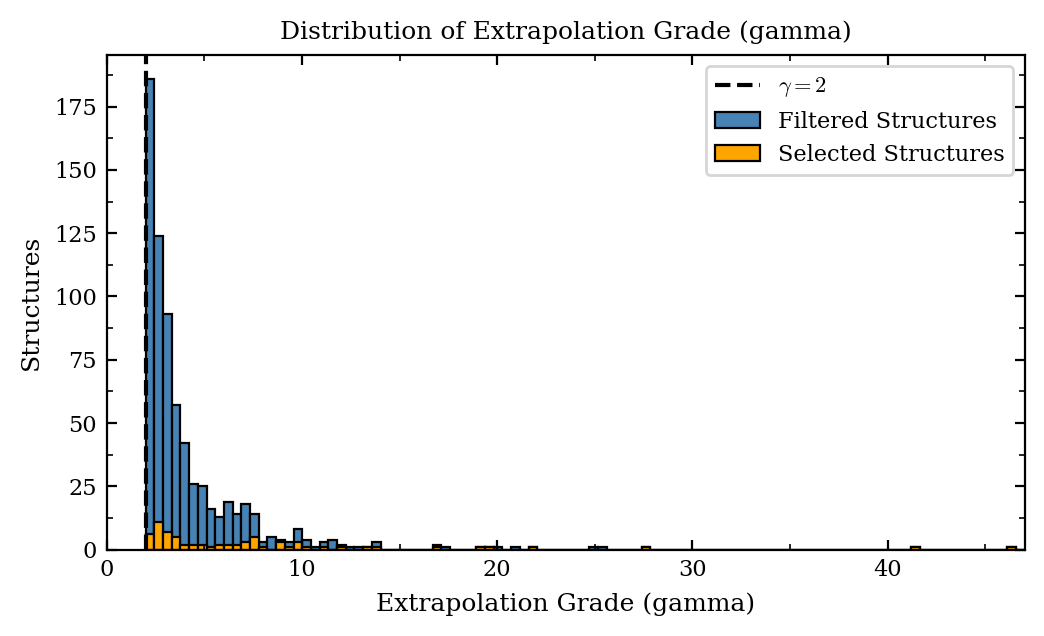

In [ ]:
# Plot distribution of gamma
import matplotlib.pyplot as plt
import math
lf = LatexFigure()

g_min = math.floor(gamma_min * 2) / 2
g_max = math.ceil(gamma_max * 2) / 2

fig, axes = lf.create(AR=0.6)

# Plot vertical line at gamma = 2
axes[0].axvline(x=2, color='black', linestyle='--', label='$\\gamma = 2$')

axes[0].hist(gamma_filtered_structures, label='Filtered Structures', range=(g_min, g_max), bins=101,
             color='steelblue', edgecolor='black', lw=0.8, alpha=1, density=False)
#axes[1].hist(gamma_filtered_structures, label='Filtered Structures', range=(0, g_max), bins=101,
#             color='green', edgecolor='black', alpha=1, density=False)
axes[0].hist(gamma_selected_structures, label='Selected Structures', range=(g_min, g_max), bins=101,
             color='orange', edgecolor='black', lw=0.8, alpha=1, density=False)
#axes[0].hist(gamma_candidates, range=(0, gamma_max), bins=101,
#             color='green', edgecolor='black', alpha=1, density=True)
#plt.hist(get_gamma(descriptors, NEP.active), bins=50, color='orange', edgecolor='black')

axes[0].set_title('Distribution of Extrapolation Grade (gamma)')
axes[0].set_xlim(0, g_max)
axes[0].set_ylabel('Structures')
axes[0].legend()

axes[0].set_xlabel('Extrapolation Grade (gamma)')

#axes[0].grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
def plot_active_set(A, idx):
    from sklearn.decomposition import PCA
    import matplotlib.pyplot as plt

    pca = PCA(n_components=2)
    A2 = pca.fit_transform(A)

    lf = LatexFigure()
    fig, axes = lf.create()
    # Plot ALL environments as a faint cloud
    axes[0].scatter(
        A2[:, 0], A2[:, 1],
        s=15,
        alpha=0.4,
        color="gray",
        label="All environments"
    )

    # Plot active set clearly
    axes[0].scatter(
        A2[idx, 0], A2[idx, 1],
        s=10,
        marker='x',
        #edgecolor="black",
        color="red",
        label="Active set"
    )
    axes[0].set_title("Active set coverage of descriptor space")
    axes[0].set_xlabel("PC1")
    axes[0].set_ylabel("PC2")
    axes[0].legend()
    #axes[0].tight_layout()
    plt.show()

In [ ]:
def check_active_set_quality(A, idx):
    import numpy as np
    import matplotlib.pyplot as plt

    sub = A[idx]
    inv = np.linalg.pinv(sub)

    # projection coefficients
    C = A @ inv  # (N, M)

    # reconstruction back in descriptor space
    A_proj = C @ sub  # (N, M)

    # relative error per atom
    residual = np.linalg.norm(A - A_proj, axis=1) / (np.linalg.norm(A, axis=1) + 1e-12)

    print(f"Mean reconstruction error: {np.mean(residual):.4e}")
    print(f"Max reconstruction error: {np.max(residual):.4e}")

    plt.hist(residual, bins=50)
    plt.title("Descriptor reconstruction error (active set quality)")
    plt.show()

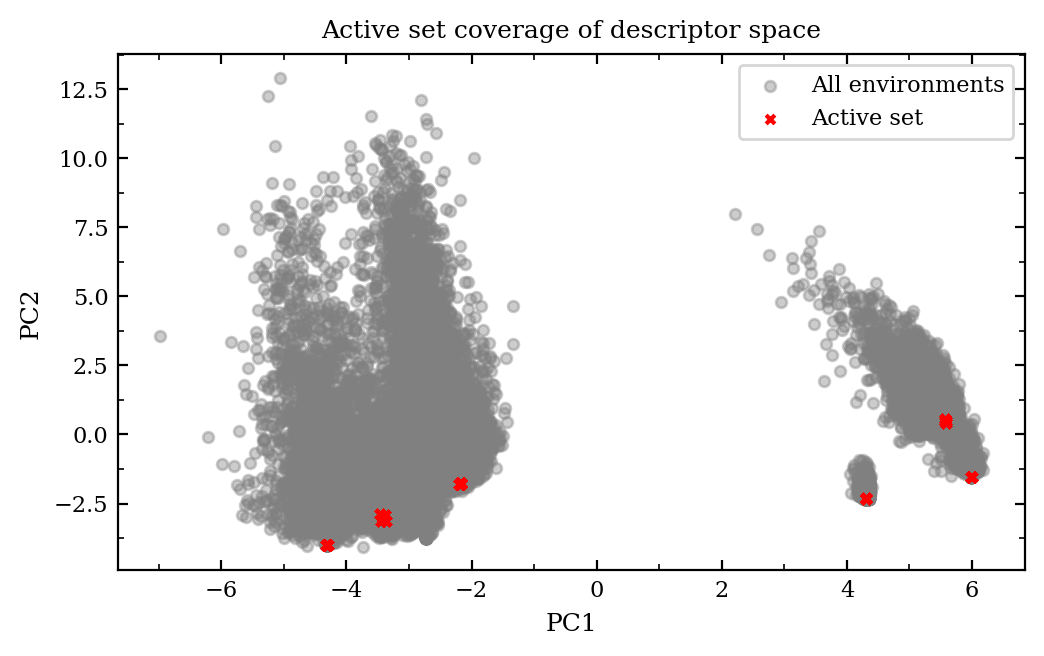

Mean reconstruction error: 5.3379e-13
Max reconstruction error: 2.0019e-12


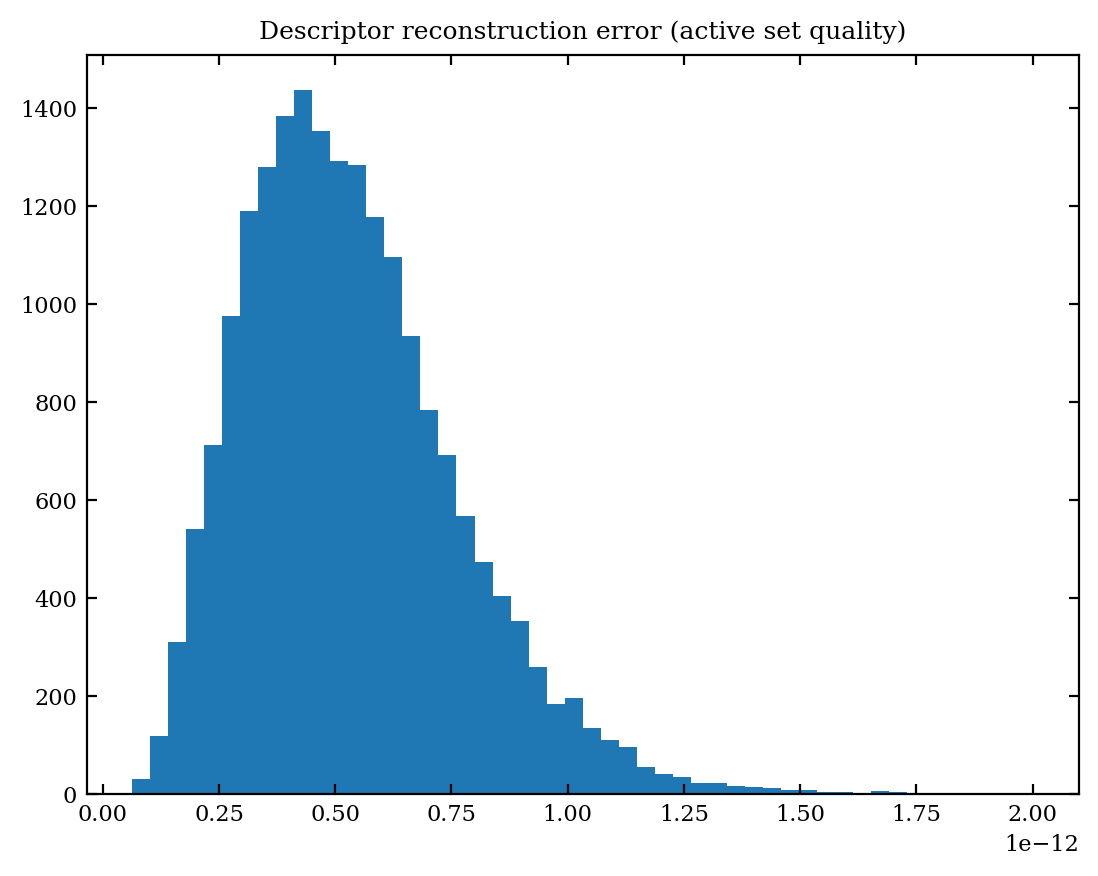

In [ ]:
plot_active_set(NEP.descriptors, NEP.active_index)
check_active_set_quality(NEP.descriptors, NEP.active_index)

In [ ]:
from ase.io import read
from calorine.calculators import CPUNEP
from calorine.tools import relax_structure, get_force_constants

/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from src.structure import Perovskite
perovskite = Perovskite('BaTiO3', N=2)
atoms = perovskite.atoms
calculator = CPUNEP('results/MLtest/iteration_1/nep.txt')
atoms.calc = calculator
relax_structure(atoms, fmax=0.00001)

/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/filters.py:606: RuntimeWarning: logm result may be inaccurate, approximate err = 2.7924169409636234e-13
  pos[natoms:] = self.logm(pos[natoms:]) * self.exp_cell_factor
/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/filters.py:606: RuntimeWarning: logm result may be inaccurate, approximate err = 2.6684850377652733e-13
  pos[natoms:] = self.logm(pos[natoms:]) * self.exp_cell_factor
/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/filters.py:606: RuntimeWarning: logm result may be inaccurate, approximate err = 2.708682935440357e-13
  pos[natoms:] = self.logm(pos[natoms:]) * self.exp_cell_factor


In [ ]:
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase.md.langevin import Langevin
from ase import units

MaxwellBoltzmannDistribution(atoms, temperature_K=300)

# 4. Set up MD (Langevin thermostat)
dyn = Langevin(
    atoms,
    timestep=1.0 * units.fs,
    temperature_K=300,
    friction=0.01
)

dyn.attach(lambda: write('results/MLtest/md.xyz', atoms, append=True), interval=10)
dyn.run(5000)

In [ ]:
from ase.visualize import view
view(read('results/MLtest/md.xyz', ':'))

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

Traceback (most recent call last):
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 34, in <module>
    main()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 30, in main
    plt.show()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/matplotlib/pyplot.py", line 613, in show
    return _get_backend_mod().show(*args, **kwargs)
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/matplotlib_inline/backend_inline.py", line 90, in show
    display(
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/IPython/core/display_functions.py", line 265, in

## Model predictions

### Phonon dispersions

In [2]:
from ase.io import read
from calorine.calculators import CPUNEP
from calorine.tools import relax_structure, get_force_constants
from src.structure import Perovskite
from src.phononcalc import plot_dispersion

/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from src.activeNEP import ActiveLearningNEP
NEP = ActiveLearningNEP('results/ALnep')

Current iteration: 2
Loaded 838 training structures and 84 test structures
All structures have calculator results.
Existing NEP model found. Loading...
Existing active set inverse (.asi) and structures (.xyz) found. Loading...


      Step     Time          Energy          fmax
BFGS:    0 15:14:17      -44.270154        0.290011
BFGS:    1 15:14:17      -44.273502        0.248689
BFGS:    2 15:14:17      -44.282691        0.004178
BFGS:    3 15:14:17      -44.282694        0.000058


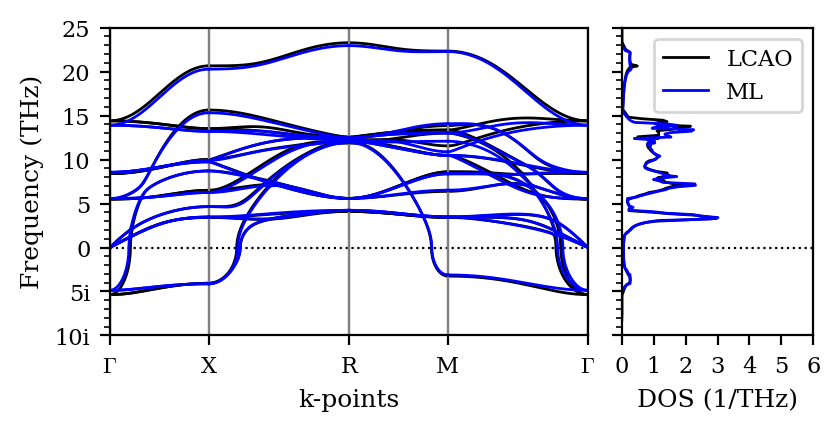

In [104]:
# Calculate phonons for the bulk unit cell structure using the trained NEP model
perovskite_bulk = Perovskite('BaTiO3')
atoms = perovskite_bulk.atoms.copy()
NEP.relax_atoms(atoms)
phonon_ML = NEP.calculate_phonon(atoms)
# Load the phonon DFT calculation results from the YAML file
phonon_LCAO = phonopy.load("results/bulk/BaTiO3/0082/phonons/BaTiO3.yaml")
fig = plot_dispersion([phonon_LCAO, phonon_ML], ['LCAO', 'ML'], width=0.8)

In [ ]:
"""
strains = np.linspace(-0.01, 0.01, 5)

phonons = []
for strain in strains:
    perovskite.set_atoms(atoms)
    perovskite.apply_strain(strain)
    if strain != 0:
        NEP.relax_atoms(perovskite.atoms, strained=True)
    else:
        NEP.relax_atoms(perovskite.atoms)
    phonon = NEP.calculate_phonon(perovskite.atoms)
    phonons.append(phonon)
"""

      Step     Time          Energy          fmax
BFGS:    0 13:45:19      -44.260969        0.184184
BFGS:    1 13:45:19      -44.261430        0.166383
BFGS:    2 13:45:20      -44.263489        0.001513
BFGS:    3 13:45:20      -44.263489        0.000012
      Step     Time          Energy          fmax
BFGS:    0 13:45:20      -44.277331        0.090975
BFGS:    1 13:45:20      -44.277443        0.082236
BFGS:    2 13:45:20      -44.277948        0.000381
BFGS:    3 13:45:20      -44.277948        0.000002
      Step     Time          Energy          fmax
BFGS:    0 13:45:20      -44.282694        0.000058
      Step     Time          Energy          fmax
BFGS:    0 13:45:20      -44.277456        0.088855
BFGS:    1 13:45:20      -44.277563        0.080430
BFGS:    2 13:45:20      -44.278049        0.000387
BFGS:    3 13:45:20      -44.278049        0.000002
      Step     Time          Energy          fmax
BFGS:    0 13:45:20      -44.262005        0.175364
BFGS:    1 13:45:20   

In [96]:
#fig = plot_dispersion(phonons, ['-0.01', '-0.005', '0.0', '0.005', '0.01'], width=0.8)

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from src.frozenphonon import get_displacement, get_unstable_mode_groups
from src.phononASE import phonon_to_atoms

# Double well potential
# ---------- Models ----------

def U_anharm(x, a, b):
    return -0.5 * a * x**2 + 0.25 * b * x**4


# ---------- Utilities ----------

def symmetrize_data(x, y):
    x_sym = np.concatenate((-x[::-1], x))
    y_sym = np.concatenate((y[::-1], y))
    return x_sym, y_sym


def extract_dw_properties(a, b):
    x0 = np.sqrt(a / b)
    barrier = a**2 / (4 * b)
    return x0, barrier


def fit_double_well(x, y):
    x, y = symmetrize_data(x, y)

    # Shift minimum to zero reference
    y = y - y[np.argmin(np.abs(x))]

    popt, _ = curve_fit(
        U_anharm,
        x,
        y,
        bounds=([0, 0], [np.inf, np.inf])
    )

    a, b = popt
    xfit = np.linspace(min(x), max(x), 1000)
    yfit = U_anharm(xfit, a, b)

    x0, barrier = extract_dw_properties(a, b)

    return x, y, xfit, yfit, x0, barrier

def displace_imaginary_modes(phonon, n_points=101, deg=True):
    """
    """
    # Get current working directory (cwd)
    #cwd = os.getcwd()
    # Unitcell and formula from phonon object
    unitcell = phonon_to_atoms(phonon, cell='unit')
    #formula = unitcell.symbols

    # Dictionary for q-points
    q_dict = {
        'G': [0.0, 0.0, 0.0],
        'X': [0.5, 0.0, 0.0],
        'M': [0.5, 0.5, 0.0],
        'R': [0.5, 0.5, 0.5],
    }

    dd_dict = {
        'G': 0.5/n_points,
        'X': 1.5/n_points,
        'M': 3/n_points,
        'R': 5/n_points,
    }

    results = {}

    for qpoint in q_dict.keys():

        q = q_dict[qpoint]
        dd = dd_dict[qpoint]

        groups, stable = get_unstable_mode_groups(phonon, q)

        if stable:
            print(f"No unstable modes found at {qpoint}")
            continue

        results[qpoint] = {}

        for g_id, group in enumerate(groups):

            modes = group["modes"]
            freq = group["frequency"]

            if not deg:
                modes = [modes[0]]

            results[qpoint][g_id] = {}

            for mode_id, modevec in enumerate(modes):

                modevec_sc, supercell, supercell_matrix = get_displacement(unitcell, q, modevec)

                nx, ny, nz = supercell_matrix.diagonal().astype(int)
                ncells = nx * ny * nz

                calc = CPUNEP(os.path.join(NEP.iter_dir, 'nep.txt'))

                supercell_disp = supercell.copy()
                ref_positions = supercell.positions.copy()
                supercell_disp.calc = calc

                amp = 0
                amplitudes = []
                energies = []
                images = []

                while True:
                    supercell_disp.positions = ref_positions + amp * modevec_sc

                    # Get energy (eV) per atom
                    energy = supercell_disp.get_potential_energy() / len(supercell_disp)

                    amplitudes.append(amp)
                    energies.append(energy)
                    images.append(supercell_disp.copy())

                    amp += dd

                    tol = 100e-3
                    if len(energies) > 1 and energies[-1] - energies[0] > tol:
                        break

                df = pd.DataFrame({
                    'Amplitude': amplitudes,
                    'Energy': energies,
                    'Structure': images
                })
                

                # Find image corresponding to the minimum energy
                min_idx = np.argmin(energies)
                atoms_min = images[min_idx].copy()
                
                x = df["Amplitude"].to_numpy()
                y = df["Energy"].to_numpy() * 1000  # meV

                x, y, xfit, yfit, x0, barrier = fit_double_well(x, y)

                # store everything
                results[qpoint][g_id][mode_id] = {
                    "df": df,
                    "frequency": freq,
                    "barrier": barrier,
                    "structure": atoms_min
                }

    return results


In [5]:
def calculate_results(perovskite, strains):

    atoms_initial = perovskite.atoms.copy()

    atoms_relax = atoms_initial.copy()
    NEP.relax_atoms(atoms_relax)

    results = {strain: {} for strain in strains}

    for strain in strains:
        perovskite.set_atoms(atoms_relax)
        perovskite.apply_strain(strain)

        if strain != 0:
            NEP.relax_atoms(perovskite.atoms, strained=True)
        #else:
            #NEP.relax_atoms(perovskite.atoms)
        
        #latticevecs[qpoint].append(perovskite.atoms.copy().cell.diagonal())

        phonon = NEP.calculate_phonon(perovskite.atoms)
        #phonons.append(phonon)
        results[strain] = displace_imaginary_modes(phonon, n_points=201, deg=False)
    
    perovskite.set_atoms(atoms_initial)
    return results


In [ ]:
"""
N = 3
mirror = False

#lf = LatexFigure()
#fig, axes = lf.create(subplots=(1, N), AR=2, sharey=True, grid=True)
#color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
for strain in strains:
    res = results[strain]
    lf = LatexFigure()
    N = len(res.keys())
    fig, axes = lf.create(subplots=(1, N), AR=2, sharey=True, grid=True)
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

    qpoints = res.keys()

    for i, q in enumerate(qpoints):

        ax = axes[i]
        color_idx = 0

        for g_id, modes in res[q].items():
            for mode_id, data in modes.items():
                df = data["df"]

                x = df["Amplitude"].to_numpy()
                y = df["Energy"].to_numpy() * 1000  # meV

                try:
                    x, y, xfit, yfit, x0, barrier = fit_double_well(x, y)
                except RuntimeError:
                    continue  # skip bad fits

                color = color_cycle[color_idx % len(color_cycle)]
                color_idx += 1

                if mirror:
                    ax.plot(xfit, yfit, '-', color=color)
                else:
                    mask = xfit >= 0
                    ax.plot(xfit[mask], yfit[mask], '-', color=color)

                # Mark origin
                ax.plot(0, 0, 'k.', markersize=4)

                # Annotate physics
                ax.text(
                    0.05,
                    0.9 - 0.1 * color_idx,
                    f"g{g_id} m{mode_id}\n"
                    f"$Q_0$={x0:.2f}\n"
                    f"$\Delta E$={barrier:.1f} meV",
                    transform=ax.transAxes,
                    fontsize=8,
                    color=color
                )

        ax.set_xlabel(r'$Q$ (amu$^{1/2}$Å)')

        if i == 0:
            ax.set_ylabel(r'$\Delta E$ (meV/u.c.)')
    plt.show()
"""

In [20]:
def unpack_results(results, qpoints):
    
    #strains = np.linspace(-0.025, 0.025, 21)

    frequencies = {q: [] for q in qpoints}
    barriers    = {q: [] for q in qpoints}
    structures  = {q: [] for q in qpoints}

    for strain in results.keys():
        res = results[strain]

        #qpoints = res.keys()

        for i, q in enumerate(qpoints):

            #ax = axes[i]
            freqs = []
            bars = []

            try:
                for g_id, modes in res[q].items():
                    for mode_id, data in modes.items():

                        freqs.append(data["frequency"])
                        bars.append(-data["barrier"])
                        #barrier = data["barrier"]
                        #ax.plot(strain, freq, '.', color='k')
            except KeyError:
                freqs = [0]
                bars = [0]
            
            frequencies[q].append(freqs)
            barriers[q].append(bars)
            structures[q].append(data["structure"])

    frequencies = {q: vals for q, vals in frequencies.items() if vals}
    barriers = {q: vals for q, vals in barriers.items() if vals}

    return frequencies, barriers, structures

In [7]:
def plot_imag_freq(strains, y_vals, y_unit='THz', width=0.9):

    N = len(y_vals.keys())

    lf = LatexFigure()
    fig, axes = lf.create(subplots=(1, N), AR=2, width=width, sharey=True, grid=True)
    #fig.set_constrained_layout_pads(wspace=0, w_pad=0)

    def _plot_by_degeneracy(ax, strains, y_vals):

        strains = np.array(strains)

        def _group_by_degeneracy(y_vals):

            y_vals_grouped = []

            for strain, y_val in zip(strains, y_vals):
                if len(y_val) == 1:
                    if strain == 0:
                        # Duplicate
                        pair = [y_val[0], y_val[0]]
                    else:
                        pair = [y_val[0], 0]
                else:
                    pair = y_val

                # optional symmetry flip
                if strain < 0:
                    pair = pair[::-1]

                y_vals_grouped.append(pair)

            return np.array(y_vals_grouped)
        
        try:
            y_vals_grouped = np.array(y_vals)
            if y_unit == 'meV':
                y_vals_grouped = -1*y_vals_grouped

            ax.plot(strains * 100, y_vals_grouped, '-', lw=1, color='red', label='in-plane')
            ax.plot(strains * 100, y_vals_grouped, '.', markersize=2, color='k')
        
        except Exception:
            y_vals_grouped = _group_by_degeneracy(y_vals)
            if y_unit == 'meV':
                y_vals_grouped = -1*y_vals_grouped

            y_lower = y_vals_grouped[:, 0]
            y_upper = y_vals_grouped[:, 1]

            ax.plot(strains * 100, y_lower, '-', lw=1, color='red', label='in-plane')
            ax.plot(strains * 100, y_upper, '-', lw=1, color='blue', label='out-of-plane')
            ax.plot(strains * 100, y_lower, '.', markersize=2, color='k')
            ax.plot(strains * 100, y_upper, '.', markersize=2, color='k')
        
        ax.set_xlim(strains[0] * 100, strains[-1] * 100)
        ax.legend(loc='lower left')

    for i, qpoint in enumerate(y_vals.keys()):
        _plot_by_degeneracy(
            axes[i],
            strains,
            y_vals[qpoint]
        )

        axes[i].set_xlabel('Bi-axial strain (%)')

        if qpoint == 'G':
            axes[i].set_title(f'$\Gamma$ point')
        else:
            axes[i].set_title(f'{qpoint} point')

    if y_unit == 'THz':
        axes[0].set_ylabel('Frequency (THz)')
    elif y_unit == 'meV':
        axes[0].set_ylabel('$\\Delta$ Energy (meV/atom)')
    axes[0].set_ylim(None, -0.03)
    
    return fig

In [135]:
strains = np.linspace(-0.025, 0.025, 21)
perovskite_bulk = Perovskite('BaTiO3')
results_bulk = calculate_results(perovskite_bulk, strains)

      Step     Time          Energy          fmax
BFGS:    0 15:26:36      -44.270154        0.290011
BFGS:    1 15:26:36      -44.273502        0.248689
BFGS:    2 15:26:36      -44.282691        0.004178
BFGS:    3 15:26:36      -44.282694        0.000058
      Step     Time          Energy          fmax
BFGS:    0 15:26:36      -44.142755        0.474232
BFGS:    1 15:26:36      -44.145810        0.427665
BFGS:    2 15:26:36      -44.159461        0.028491
BFGS:    3 15:26:36      -44.159536        0.004972
BFGS:    4 15:26:36      -44.159538        0.000017
No unstable modes found at R
      Step     Time          Energy          fmax
BFGS:    0 15:26:39      -44.169517        0.425409
BFGS:    1 15:26:39      -44.171976        0.383750
BFGS:    2 15:26:39      -44.182908        0.017995
BFGS:    3 15:26:39      -44.182938        0.003338
BFGS:    4 15:26:39      -44.182939        0.000007
No unstable modes found at R
      Step     Time          Energy          fmax
BFGS:    0 15:

In [ ]:
frequencies, barriers, structures = unpack_results(results_bulk, qpoints=['G', 'X', 'M'])

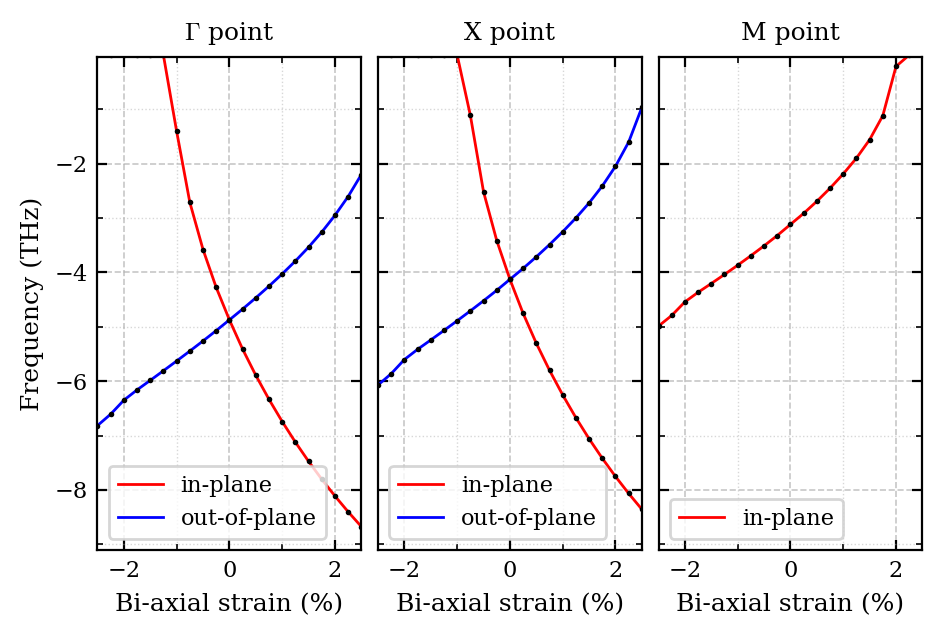

In [ ]:
fig1 = plot_imag_freq(strains, frequencies)
fig1.savefig('figures/NEP_bulk_freq_strain.pdf', bbox_inches='tight')
fig2 = plot_imag_freq(strains, barriers, y_unit='meV')
fig2.savefig('figures/NEP_bulk_dE_strain.pdf', bbox_inches='tight')

In [144]:
indx = np.where(strains == 0)[0][0]
perovskite_bulk = Perovskite('BaTiO3')
perovskite_bulk.set_atoms(structures['G'][indx])
NEP.relax_atoms(perovskite_bulk.atoms, fmax=0.001)

      Step     Time          Energy          fmax
BFGS:    0 15:29:43      -44.286920        0.155548
BFGS:    1 15:29:43      -44.287387        0.139229
BFGS:    2 15:29:43      -44.289267        0.086652
BFGS:    3 15:29:43      -44.289473        0.092754
BFGS:    4 15:29:43      -44.291505        0.091862
BFGS:    5 15:29:43      -44.291850        0.056152
BFGS:    6 15:29:43      -44.292061        0.051058
BFGS:    7 15:29:43      -44.292176        0.030634
BFGS:    8 15:29:43      -44.292269        0.035583
BFGS:    9 15:29:43      -44.292357        0.036609
BFGS:   10 15:29:43      -44.292450        0.037836
BFGS:   11 15:29:43      -44.292701        0.070839
BFGS:   12 15:29:43      -44.292978        0.088056
BFGS:   13 15:29:43      -44.293559        0.086568
BFGS:   14 15:29:43      -44.294598        0.061542
BFGS:   15 15:29:43      -44.294990        0.054565
BFGS:   16 15:29:43      -44.295123        0.061870
BFGS:   17 15:29:43      -44.295303        0.047004
BFGS:   18 15:

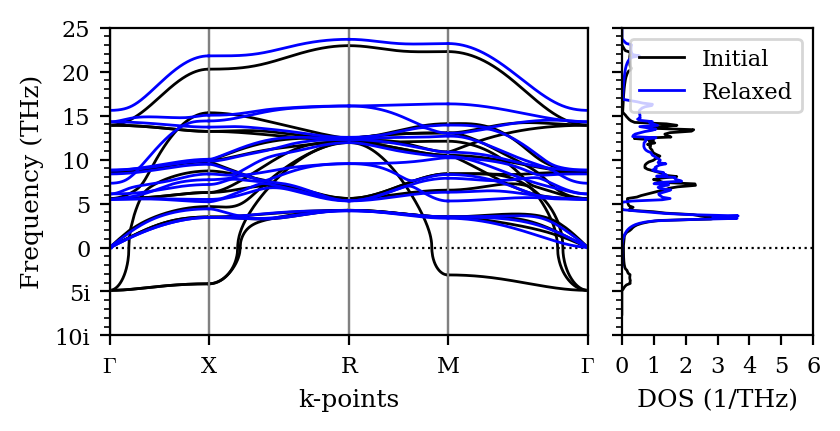

In [145]:
phonon_initial = NEP.calculate_phonon(atoms)
phonon_relaxed = NEP.calculate_phonon(perovskite_bulk.atoms)
fig = plot_dispersion([phonon_initial, phonon_relaxed], ['Initial', 'Relaxed'], width=0.8)

### Slabs

      Step     Time          Energy          fmax
BFGS:    0 16:09:49      -69.803858        2.195412
BFGS:    1 16:09:49      -69.983950        1.471366
BFGS:    2 16:09:49      -70.213438        0.841101
BFGS:    3 16:09:49      -70.250141        0.752768
BFGS:    4 16:09:49      -70.363773        0.092451
BFGS:    5 16:09:49      -70.364745        0.098006
BFGS:    6 16:09:49      -70.366529        0.094474
BFGS:    7 16:09:49      -70.368579        0.074477
BFGS:    8 16:09:49      -70.370868        0.050654
BFGS:    9 16:09:49      -70.371673        0.022330
BFGS:   10 16:09:49      -70.371780        0.003865
BFGS:   11 16:09:49      -70.371785        0.000122
BFGS:   12 16:09:49      -70.371785        0.000020


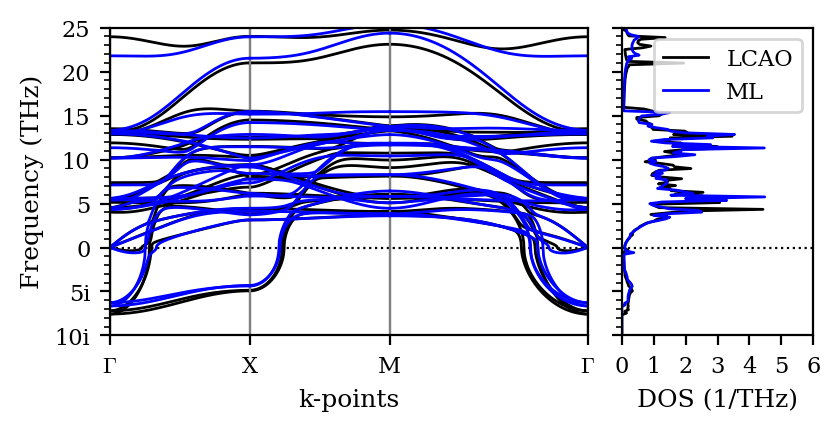

In [8]:
# Calculate phonons for the 1.5 unit cell slab structure using the trained NEP model
perovskite_slab_15 = Perovskite('BaTiO3', bulk=False, dslab=1.5)
atoms_slab_15 = perovskite_slab_15.atoms.copy()
NEP.relax_atoms(atoms_slab_15)
phonon_ML = NEP.calculate_phonon(atoms_slab_15)
# Load the phonon DFT calculation results from the YAML file
phonon_LCAO = phonopy.load("results/slab/BaTiO3/1.5uc/0001/phonons/BaTiO3.yaml")
fig = plot_dispersion([phonon_LCAO, phonon_ML], ['LCAO', 'ML'], width=0.8)

In [21]:
strains = np.linspace(-0.025, 0.025, 21)
perovskite_slab_15 = Perovskite('BaTiO3', bulk=False, dslab=1.5)
results_slab_15 = calculate_results(perovskite_slab_15, strains)

      Step     Time          Energy          fmax
BFGS:    0 16:15:48      -69.803858        2.195412
BFGS:    1 16:15:48      -69.983950        1.471366
BFGS:    2 16:15:48      -70.213438        0.841101
BFGS:    3 16:15:48      -70.250141        0.752768
BFGS:    4 16:15:48      -70.363773        0.092451
BFGS:    5 16:15:48      -70.364745        0.098006
BFGS:    6 16:15:48      -70.366529        0.094474
BFGS:    7 16:15:48      -70.368579        0.074477
BFGS:    8 16:15:48      -70.370868        0.050654
BFGS:    9 16:15:48      -70.371673        0.022330
BFGS:   10 16:15:48      -70.371780        0.003865
BFGS:   11 16:15:48      -70.371785        0.000122
BFGS:   12 16:15:48      -70.371785        0.000020
      Step     Time          Energy          fmax
BFGS:    0 16:15:48      -70.175481        0.217624
BFGS:    1 16:15:48      -70.178093        0.199596
BFGS:    2 16:15:48      -70.194812        0.197372
BFGS:    3 16:15:48      -70.195915        0.149347
BFGS:    4 16:15

In [22]:
frequencies, barriers, structures = unpack_results(results_slab_15, qpoints=['G', 'X'])

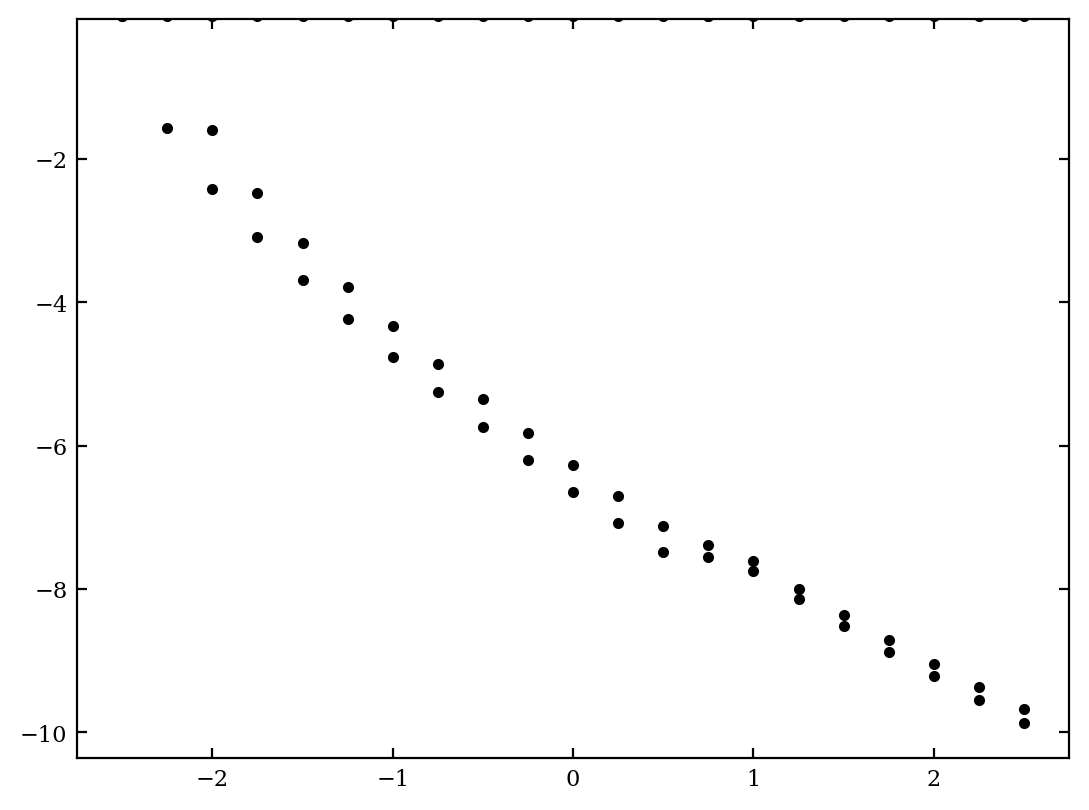

In [23]:
for i, strain in enumerate(strains):
    y = np.array(frequencies['G'][i])
    x = np.ones(len(y)) * strain * 100
    plt.plot(x, y, 'k.')

plt.ylim(None, -0.05)

plt.show()

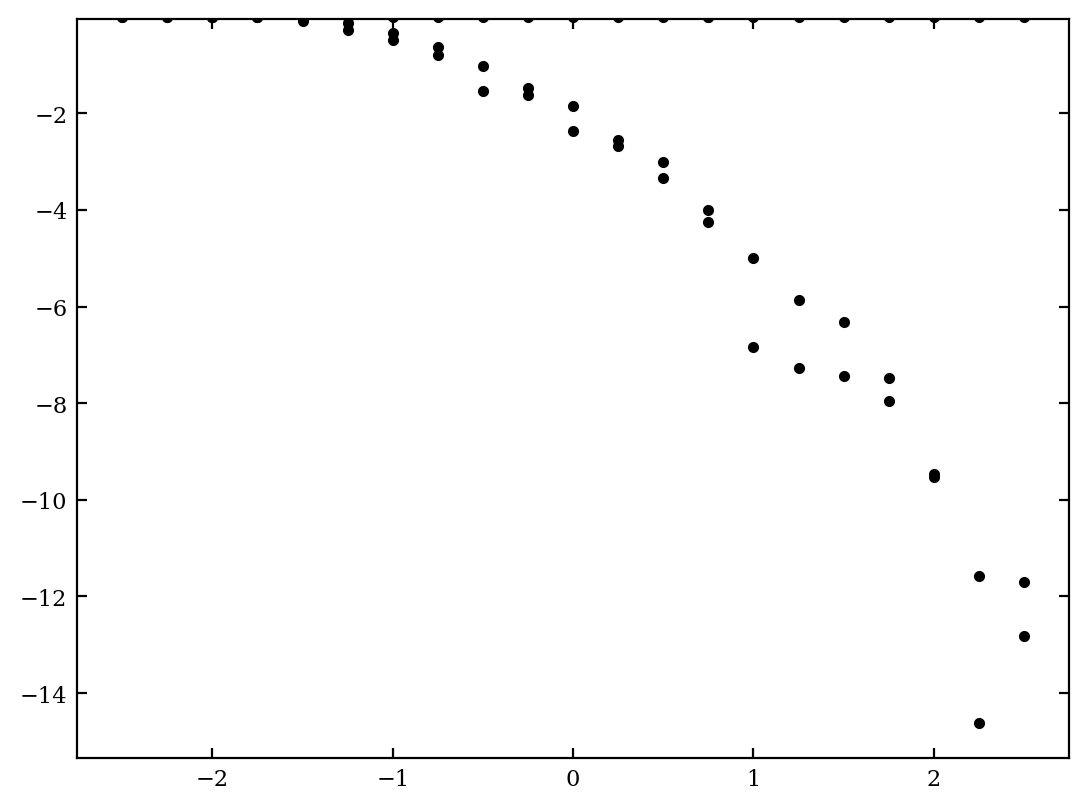

In [29]:
for i, strain in enumerate(strains):
    y = np.array(barriers['G'][i])
    x = np.ones(len(y)) * strain * 100
    plt.plot(x, y, 'k.')

plt.ylim(None, -0.05)

plt.show()

In [48]:
indx = np.where(strains == 0)[0][0]
perovskite_slab_15 = Perovskite('BaTiO3', bulk=False, dslab=1.5)
atoms_initial = perovskite_slab_15.atoms.copy()
NEP.relax_atoms(atoms_initial, fmax=0.001)
#perovskite_slab_15.set_atoms(structures['G'][indx])
atoms_final = structures['G'][indx]
NEP.relax_atoms(atoms_final, fmax=0.001)
#atoms_final = perovskite_slab_15.atoms.copy()

      Step     Time          Energy          fmax
BFGS:    0 16:29:08      -69.803858        2.195412
BFGS:    1 16:29:08      -69.983950        1.471366
BFGS:    2 16:29:08      -70.213438        0.841101
BFGS:    3 16:29:08      -70.250141        0.752768
BFGS:    4 16:29:08      -70.363773        0.092451
BFGS:    5 16:29:08      -70.364745        0.098006
BFGS:    6 16:29:08      -70.366529        0.094474
BFGS:    7 16:29:08      -70.368579        0.074477
BFGS:    8 16:29:08      -70.370868        0.050654
BFGS:    9 16:29:08      -70.371673        0.022330
BFGS:   10 16:29:08      -70.371780        0.003865
BFGS:   11 16:29:08      -70.371785        0.000122
BFGS:   12 16:29:08      -70.371785        0.000020
BFGS:   13 16:29:08      -70.371785        0.000002
BFGS:   14 16:29:08      -70.371785        0.000000
      Step     Time          Energy          fmax
BFGS:    0 16:29:08      -70.371785        0.000001


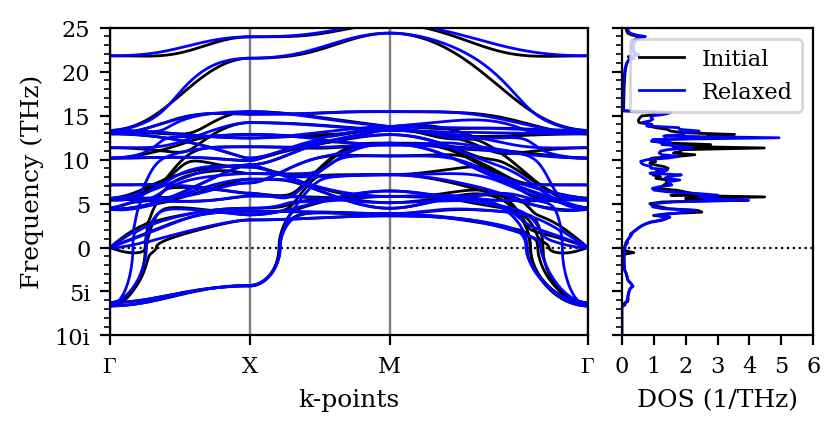

In [ ]:
phonon_initial = NEP.calculate_phonon(atoms_initial)
phonon_relaxed = NEP.calculate_phonon(atoms_initial, Nc=4)
fig = plot_dispersion([phonon_initial, phonon_relaxed], ['2x2x1', '4x4x1'], width=0.8)

      Step     Time          Energy          fmax
BFGS:    0 15:52:43     -114.132345        2.315645
BFGS:    1 15:52:43     -114.321990        1.550797
BFGS:    2 15:52:43     -114.515094        1.007144
BFGS:    3 15:52:43     -114.567973        0.699388
BFGS:    4 15:52:43     -114.645507        0.540393
BFGS:    5 15:52:43     -114.669963        0.406161
BFGS:    6 15:52:43     -114.689152        0.437384
BFGS:    7 15:52:43     -114.709387        0.371785
BFGS:    8 15:52:43     -114.722542        0.189909
BFGS:    9 15:52:43     -114.727963        0.177898
BFGS:   10 15:52:43     -114.730354        0.104835
BFGS:   11 15:52:43     -114.732148        0.062695
BFGS:   12 15:52:43     -114.732993        0.055702
BFGS:   13 15:52:43     -114.733371        0.054526
BFGS:   14 15:52:43     -114.733707        0.060319
BFGS:   15 15:52:43     -114.734275        0.088667
BFGS:   16 15:52:43     -114.735029        0.090268
BFGS:   17 15:52:43     -114.735576        0.051221
BFGS:   18 15:

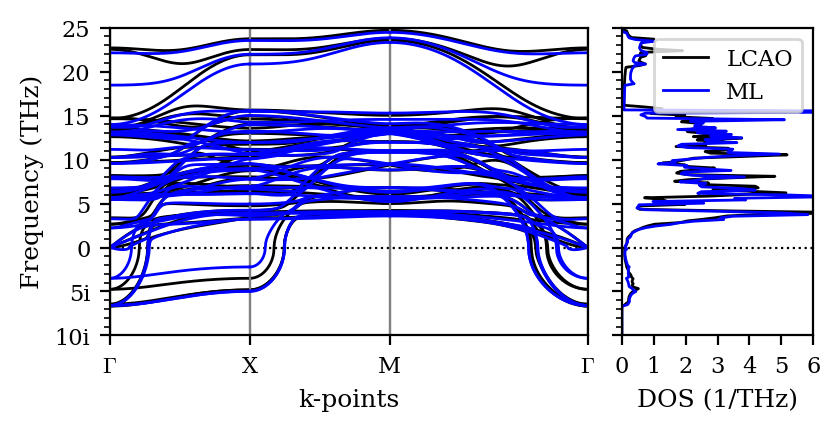

In [188]:
# Calculate phonons for the 2.5 unit cell slab structure using the trained NEP model
perovskite_slab_25 = Perovskite('BaTiO3', bulk=False, dslab=2.5).atoms
NEP.relax_atoms(perovskite_slab_25)
phonon_ML = NEP.calculate_phonon(perovskite_slab_25)
# Load the phonon DFT calculation results from the YAML file
phonon_LCAO = phonopy.load("results/slab/BaTiO3/2.5uc/0001/phonons/BaTiO3.yaml")
fig = plot_dispersion([phonon_LCAO, phonon_ML], ['LCAO', 'ML'], width=0.8)

In [189]:
strains = np.linspace(-0.025, 0.025, 21)
perovskite_slab_25 = Perovskite('BaTiO3', bulk=False, dslab=2.5)
results_slab_25 = calculate_results(perovskite_slab_25, strains)

      Step     Time          Energy          fmax
BFGS:    0 15:52:56     -114.132345        2.315645
BFGS:    1 15:52:56     -114.321990        1.550797
BFGS:    2 15:52:56     -114.515094        1.007144
BFGS:    3 15:52:56     -114.567973        0.699388
BFGS:    4 15:52:56     -114.645507        0.540393
BFGS:    5 15:52:56     -114.669963        0.406161
BFGS:    6 15:52:56     -114.689152        0.437384
BFGS:    7 15:52:56     -114.709387        0.371785
BFGS:    8 15:52:56     -114.722542        0.189909
BFGS:    9 15:52:56     -114.727963        0.177898
BFGS:   10 15:52:56     -114.730354        0.104835
BFGS:   11 15:52:56     -114.732148        0.062695
BFGS:   12 15:52:56     -114.732993        0.055702
BFGS:   13 15:52:56     -114.733371        0.054526
BFGS:   14 15:52:56     -114.733707        0.060319
BFGS:   15 15:52:56     -114.734275        0.088667
BFGS:   16 15:52:56     -114.735029        0.090268
BFGS:   17 15:52:56     -114.735576        0.051221
BFGS:   18 15:

In [192]:
frequencies, barriers, structures = unpack_results(results_slab_25, qpoints=['G', 'X'])

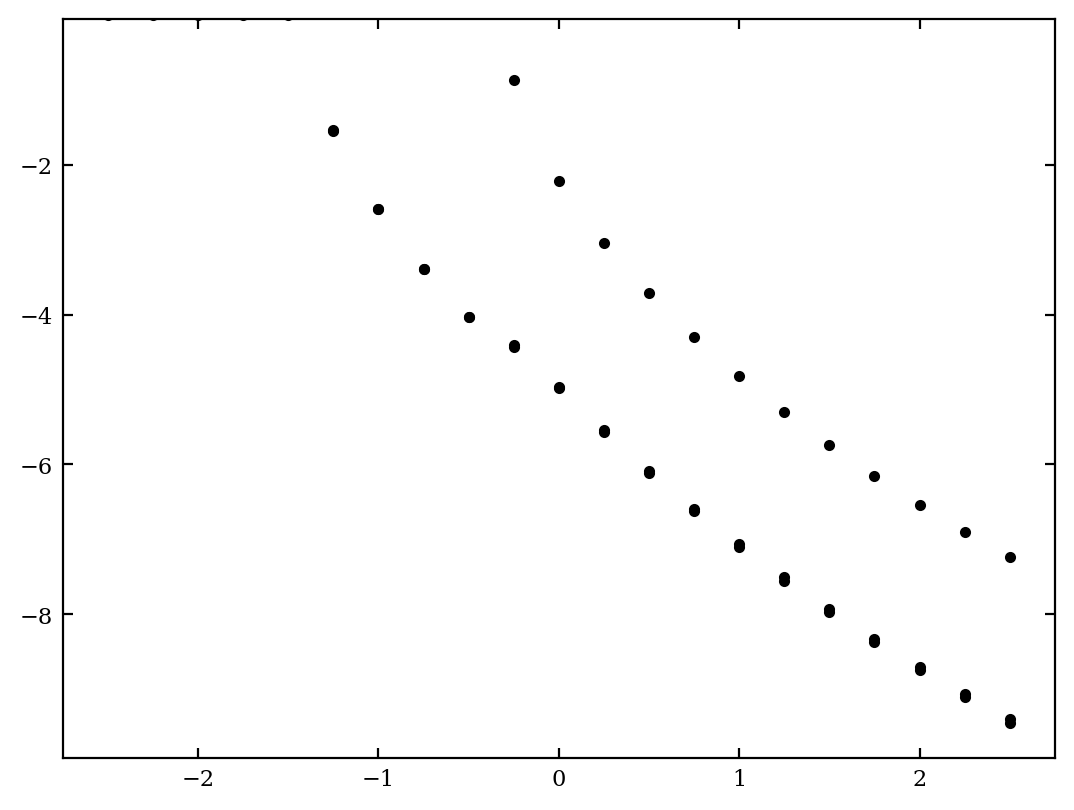

In [194]:
for i, strain in enumerate(strains):
    y = np.array(frequencies['X'][i])
    x = np.ones(len(y)) * strain * 100
    plt.plot(x, y, 'k.')

plt.ylim(None, -0.05)

plt.show()

### Molecular Dynamics

In [2]:
NEP = ActiveLearningNEP('results/ALnep')

Current iteration: 2


Loaded 838 training structures and 84 test structures
All structures have calculator results.
Existing NEP model found. Loading...
Existing active set inverse (.asi) and structures (.xyz) found. Loading...


In [3]:
# Setup MD production run with 'nve' ensemble at different temperatures
NEP.setup_MD_production(ensemble='nve', dt=1, n_steps=1e4, n_dump=500,
                        temperatures=[100, 200, 300, 400, 500, 600])

      Step     Time          Energy          fmax
BFGS:    0 10:41:04     -458.938880        0.074956
BFGS:    1 10:41:04     -458.939536        0.048642
BFGS:    2 10:41:04     -458.940632        0.036447
BFGS:    3 10:41:04     -458.940905        0.034751
BFGS:    4 10:41:04     -458.941389        0.029999
BFGS:    5 10:41:04     -458.941743        0.030428
BFGS:    6 10:41:04     -458.942305        0.038296
BFGS:    7 10:41:04     -458.942641        0.024376
BFGS:    8 10:41:04     -458.942750        0.009762
BFGS:    9 10:41:04     -458.942768        0.009963
BFGS:   10 10:41:04     -458.942778        0.010014
BFGS:   11 10:41:04     -458.942796        0.009562
BFGS:   12 10:41:04     -458.942817        0.008351
BFGS:   13 10:41:05     -458.942838        0.007646
BFGS:   14 10:41:05     -458.942859        0.007460
BFGS:   15 10:41:05     -458.942889        0.009065
BFGS:   16 10:41:05     -458.942924        0.009757
BFGS:   17 10:41:05     -458.942949        0.005823
BFGS:   18 10:

In [ ]:
view(read('results/ALnep/iteration_2/md_production/Ba4O20Ti8/600K/dump.xyz', index=':'))

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

Traceback (most recent call last):
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 34, in <module>
    main()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 30, in main
    plt.show()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/matplotlib/pyplot.py", line 613, in show
    return _get_backend_mod().show(*args, **kwargs)
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/matplotlib_inline/backend_inline.py", line 90, in show
    display(
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/IPython/core/display_functions.py", line 265, in

In [21]:
import numpy as np

def load_thermo(thermo_file, run_file):
    import re

    with open(run_file, 'r') as f:
        run_in = f.read()

    replicate = np.array(re.findall(r'replicate\s+(\d+)\s+(\d+)\s+(\d+)', run_in)[0], dtype=int)
    time_step = np.array(re.findall(r'time_step\s+(\d+\.?\d*)', run_in), dtype=float)
    dump_thermo = np.array(re.findall(r'dump_thermo\s+(\d+)', run_in), dtype=int)
    n_steps = np.array(re.findall(r'run\s+(\d+)', run_in), dtype=int)

    N_steps = np.sum(n_steps)
    N_dumps = np.sum(n_steps // dump_thermo)

    t = np.linspace(0, N_steps*time_step, N_dumps)
    data = np.loadtxt(thermo_file)
    Ndata = data.shape[0]

    def _get_lattice_constants(cell):
        a = np.linalg.norm(cell[:, 0], axis=1)
        b = np.linalg.norm(cell[:, 1], axis=1)
        c = np.linalg.norm(cell[:, 2], axis=1)
        return np.array([a, b, c])

    return {
        "t": t[:Ndata],     # time in fs
        "T": data[:, 0],    # temperature in K
        "K": data[:, 1],    # kinetic energy in eV
        "U": data[:, 2],    # potential energy in eV
        "Pxx": data[:, 3],  # pressure components in GPa
        "Pyy": data[:, 4],  
        "Pzz": data[:, 5],
        "Pyz": data[:, 6],
        "Pxz": data[:, 7],
        "Pxy": data[:, 8],
        "cell": _get_lattice_constants(data[:, 9:].reshape(-1, 3, 3)) / replicate[:, np.newaxis]
    }

In [73]:
# read thermo.out and extract temperature and energy
thermo_file = 'results/ALnep/iteration_2/md_production/Ba8O24Ti8/100K/thermo.out'
run_file = 'results/ALnep/iteration_2/md_production/Ba8O24Ti8/100K/run.in'
thermo = load_thermo(thermo_file, run_file)

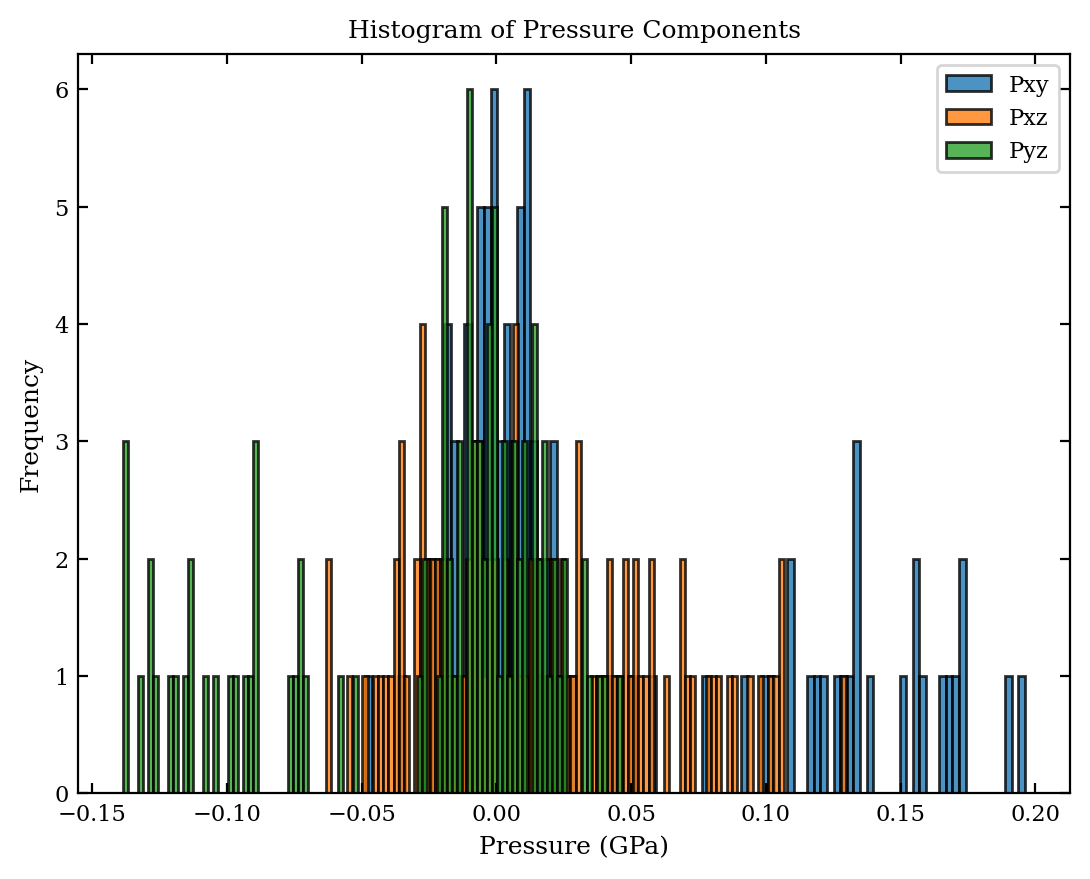

In [74]:
# Plot histogram of Pxy, Pxz, and Pyz
plt.hist(thermo["Pxy"], bins=100, alpha=0.8, edgecolor='black', label='Pxy')
plt.hist(thermo["Pxz"], bins=100, alpha=0.8, edgecolor='black', label='Pxz')
plt.hist(thermo["Pyz"], bins=100, alpha=0.8, edgecolor='black', label='Pyz')
plt.xlabel('Pressure (GPa)')
plt.ylabel('Frequency')
plt.title('Histogram of Pressure Components')
plt.legend()
plt.show()

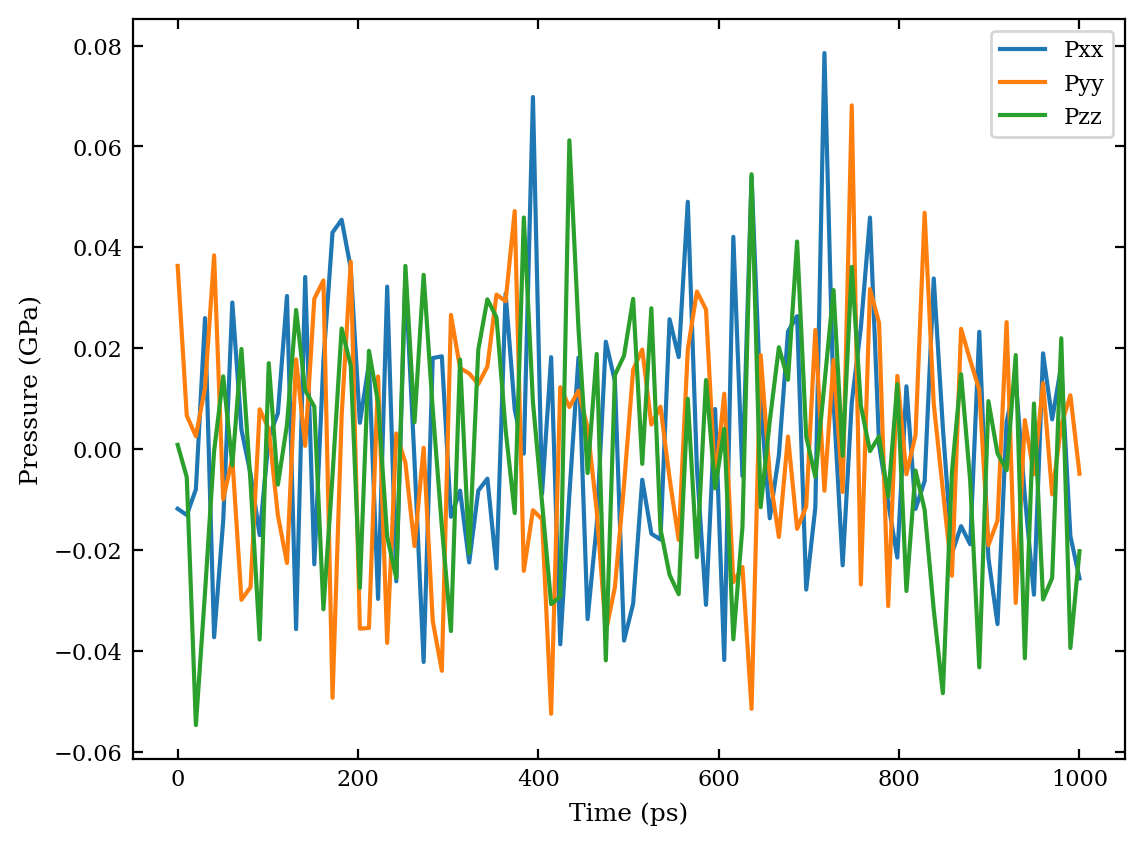

In [78]:
plt.plot(thermo['t']/1e3, thermo['Pxx'], label='Pxx')
plt.plot(thermo['t']/1e3, thermo['Pyy'], label='Pyy')
plt.plot(thermo['t']/1e3, thermo['Pzz'], label='Pzz')
#plt.plot(thermo['t']/1e3, thermo['cell'][2], label='c')
plt.xlabel('Time (ps)')
#plt.ylabel('Lattice Constant (Å/u.c.)')
plt.ylabel('Pressure (GPa)')
plt.legend()
plt.show()

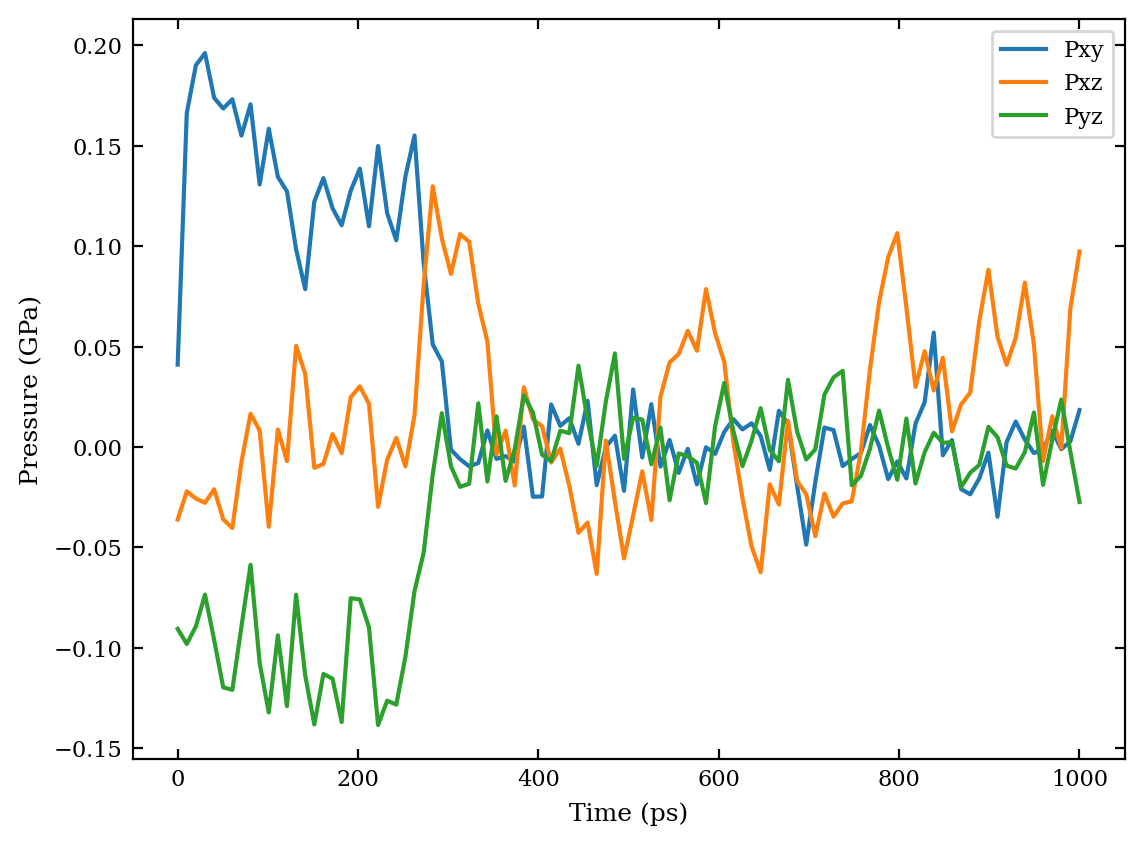

In [75]:
plt.plot(thermo['t']/1e3, thermo['Pxy'], label='Pxy')
plt.plot(thermo['t']/1e3, thermo['Pxz'], label='Pxz')
plt.plot(thermo['t']/1e3, thermo['Pyz'], label='Pyz')
#plt.plot(thermo['t']/1e3, thermo['cell'][2], label='c')
plt.xlabel('Time (ps)')
#plt.ylabel('Lattice Constant (Å/u.c.)')
plt.ylabel('Pressure (GPa)')
plt.legend()
plt.show()

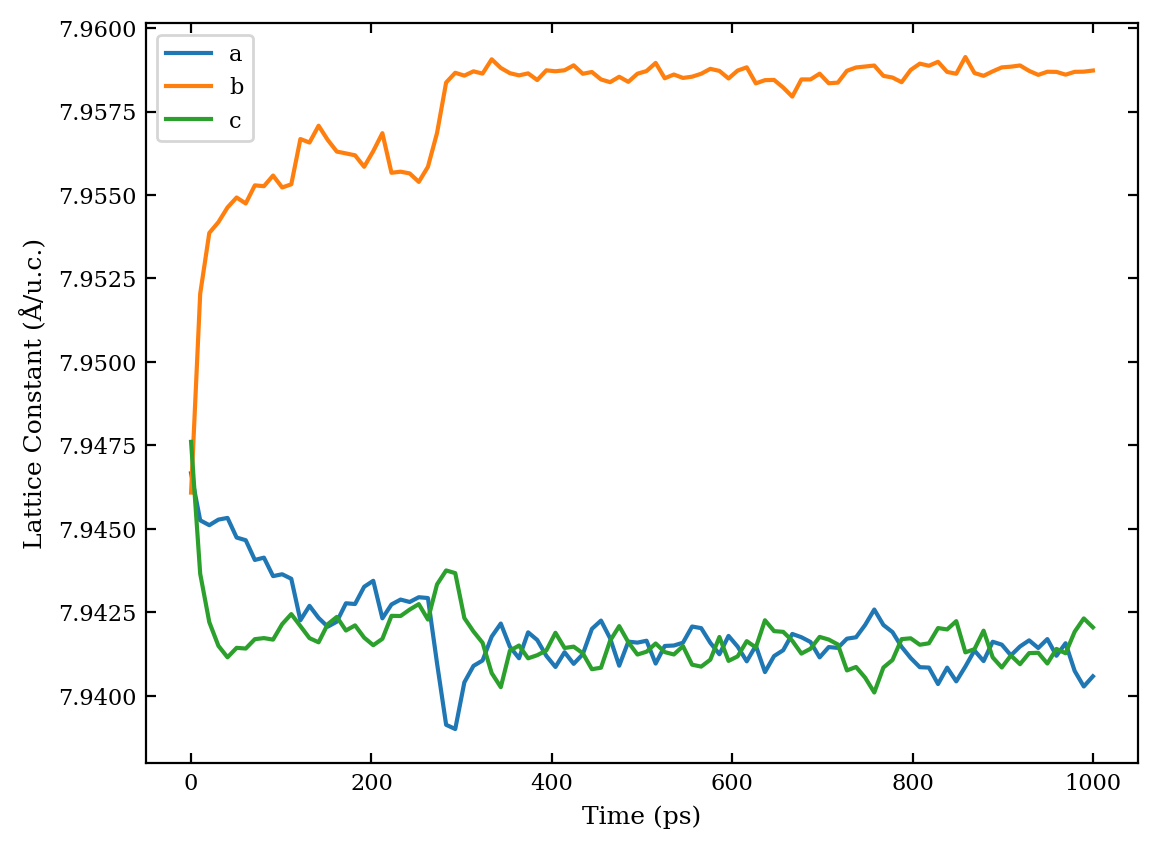

In [77]:
plt.plot(thermo['t']/1e3, thermo['cell'][0], label='a')
plt.plot(thermo['t']/1e3, thermo['cell'][1], label='b')
plt.plot(thermo['t']/1e3, thermo['cell'][2], label='c')
plt.xlabel('Time (ps)')
plt.ylabel('Lattice Constant (Å/u.c.)')
plt.legend()
plt.show()

In [62]:
a = np.array([])
b = np.array([])
c = np.array([])
T = np.array([])

for temp in [100, 200, 300, 400, 500, 600]:
    thermo_file = f'results/ALnep/iteration_2/md_production/Ba8O32Ti12/{temp}K/thermo.out'
    run_file = f'results/ALnep/iteration_2/md_production/Ba8O32Ti12/{temp}K/run.in'
    thermo = load_thermo(thermo_file, run_file)

    indx = np.where(thermo['t'] > 800*1e3)[0][0]

    T = np.append(T, thermo['T'][indx:])
    a = np.append(a, thermo['cell'][0][indx:])
    b = np.append(b, thermo['cell'][1][indx:])
    c = np.append(c, thermo['cell'][2][indx:])

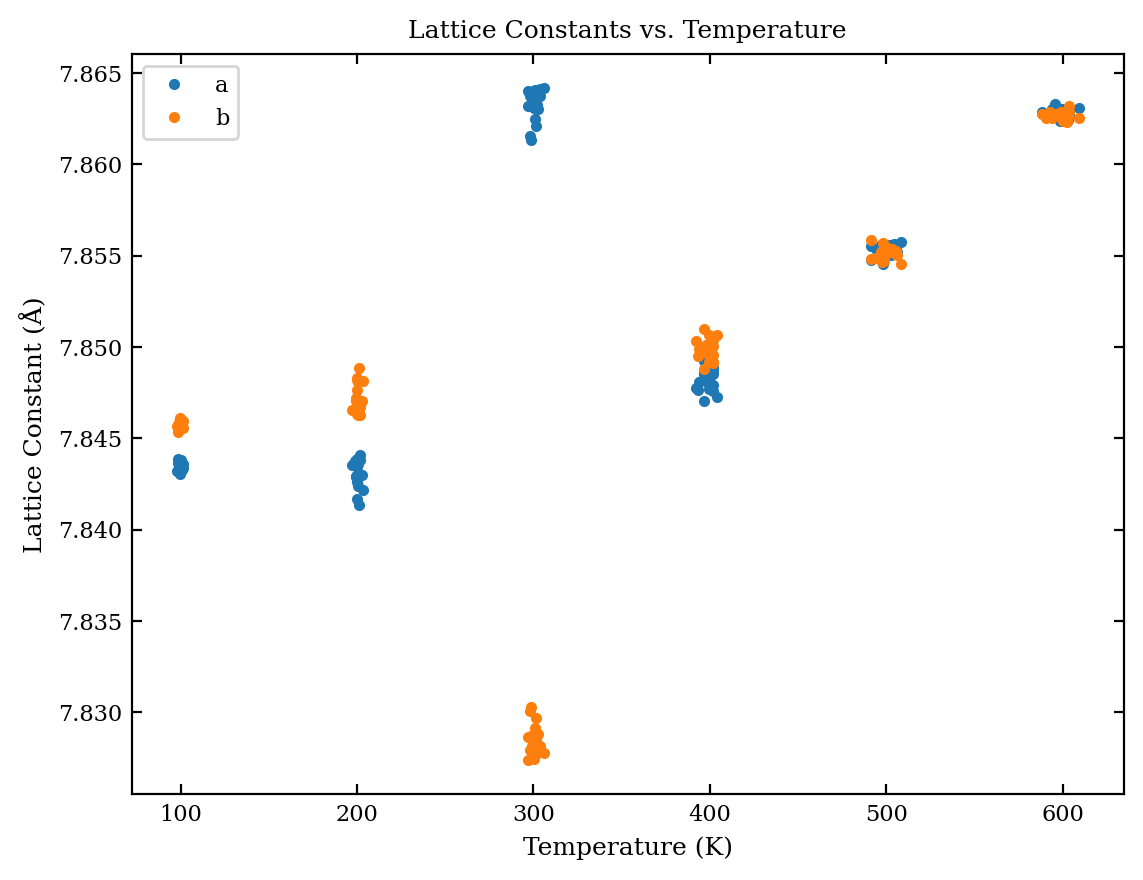

In [63]:
plt.plot(T, a, '.', label='a')
plt.plot(T, b, '.', label='b')
#plt.plot(T, c, '.', label='c')
plt.xlabel('Temperature (K)')
plt.ylabel('Lattice Constant (Å)')
plt.title('Lattice Constants vs. Temperature')
plt.legend()
plt.show()

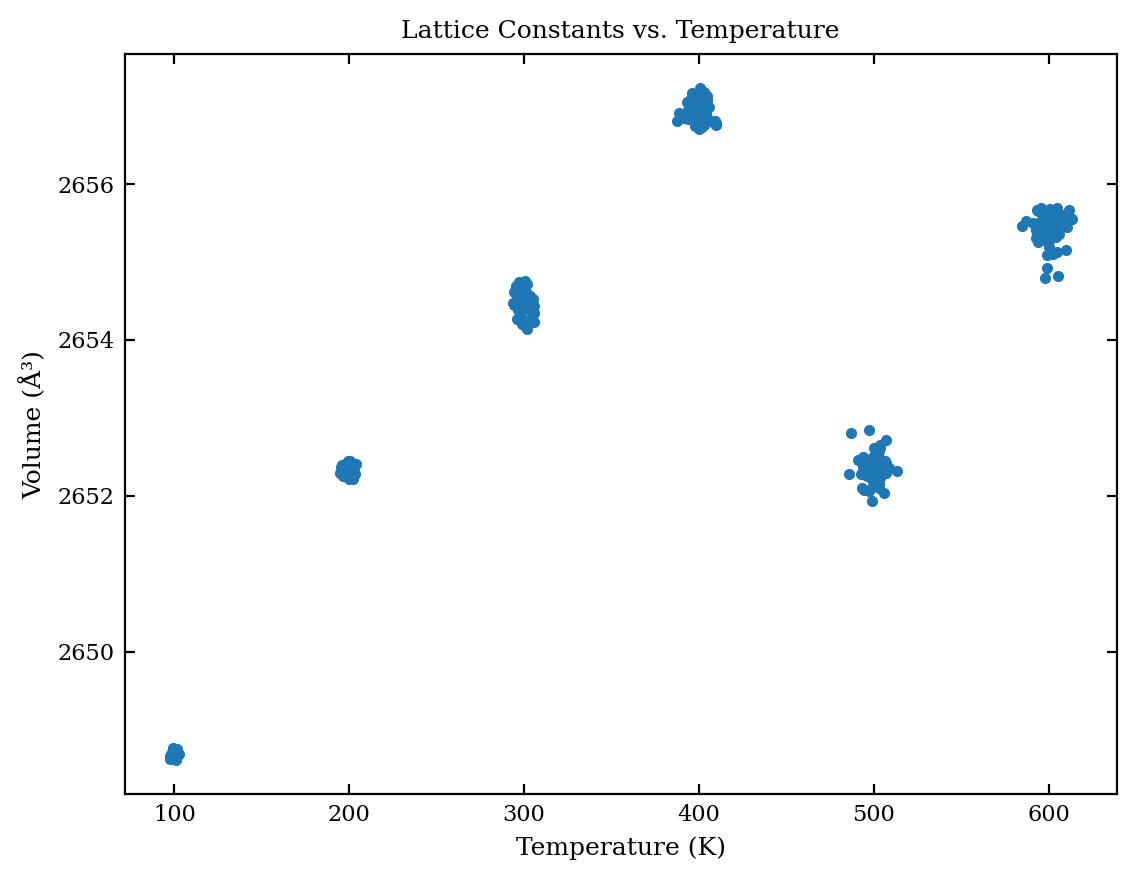

In [57]:
plt.plot(T, a*b*c, '.')
plt.xlabel('Temperature (K)')
plt.ylabel('Volume (Å³)')
plt.title('Lattice Constants vs. Temperature')
#plt.legend()
plt.show()

### Spectral Energy Density (SED)

In [2]:
from src.structure import Perovskite
from src.phononcalc import get_phonon_dispersion, plot_dispersion

In [3]:
NEP = ActiveLearningNEP('results/ALnep')
perovskite_bulk = Perovskite('BaTiO3')
atoms = perovskite_bulk.atoms.copy()
NEP.relax_atoms(atoms)
phonon_ML = NEP.calculate_phonon(atoms)

Current iteration: 2
Loaded 838 training structures and 84 test structures
All structures have calculator results.
Existing NEP model found. Loading...
Existing active set inverse (.asi) and structures (.xyz) found. Loading...
      Step     Time          Energy          fmax
BFGS:    0 14:56:16      -44.270154        0.290011
BFGS:    1 14:56:16      -44.273502        0.248689
BFGS:    2 14:56:16      -44.282691        0.004178
BFGS:    3 14:56:16      -44.282694        0.000058


In [4]:
dim = (20, 20, 20)
supercell = atoms.repeat(dim)

In [5]:
distances, frequencies, paths, pathlabels = get_phonon_dispersion(phonon_ML)

ValueError: 'Ti' is not in list

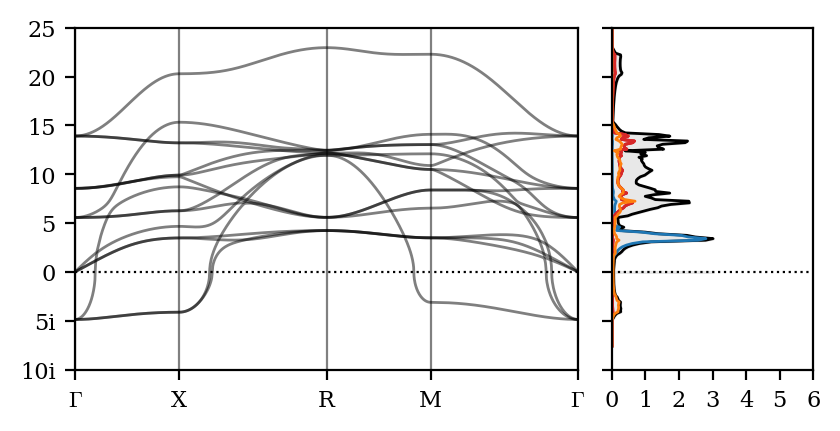

In [6]:
fig = plot_dispersion([phonon_ML], ['ML'], width=0.8)

In [9]:
import dynasor
print(dynasor.__file__)

ModuleNotFoundError: No module named 'dynasor'

In [1]:
# get qpoints
from dynasor.qpoints.lattice import Lattice

lat = Lattice(atoms.cell, supercell.cell)

dyna_paths, dyna_dists = [], []
for p, d in zip(paths, distances):
    p0, p1 = p[[0, -1]]

    dyna_path, dyna_dist = lat.make_path(p0, p1)
    dyna_paths.append(dyna_path)

    d0, d1 = d[[0, -1]]
    dyna_dists.append(d0 + (d1 - d0) * dyna_dist)

ModuleNotFoundError: No module named 'dynasor'

In [ ]:
ax = fig_phonopy_dispersion.get_axes()[0]
for x0 in np.hstack(dyna_dists):
    ax.axvline(x0, 0, 1, ls=':', color='gray', alpha=0.4)
fig_phonopy_dispersion

In [ ]:
from dynasor import Trajectory, compute_spectral_energy_density
from dynasor.units import radians_per_fs_to_THz

traj = Trajectory(f'{calc.directory}/dump.xyz', trajectory_format='extxyz')

w, sed = compute_spectral_energy_density(
        traj,
        ideal_supercell=supercell,
        primitive_cell=prim,
        q_points=dynasor_path,
        dt=dt*dump)

freqs = w * radians_per_fs_to_THz

In [ ]:
ax = fig_phonopy_dispersion.get_axes()[0]
for x0 in np.hstack(dyna_dists):
    ax.axvline(x0, 0, 1, ls=':', color='gray', alpha=0.4)
fig_phonopy_dispersion

# Tests

In [13]:
from src.structure import Perovskite
perovskite = Perovskite('BaTiO3')
atoms = perovskite.atoms
calculator = CPUNEP('results/MLtest/nepmodel_split1/nep.txt')
atoms.calc = calculator
relax_structure(atoms, fmax=0.00001)

In [14]:
atoms.cell

Cell([[3.961134456663261, -1.739646449265033e-18, 2.3777005252795005e-18], [3.2816032633461203e-17, 3.9611344566632525, -4.53674797921587e-15], [4.013580058709373e-17, -4.467379310396215e-15, 3.9611344566632507]])

In [58]:
phonon_ML = get_force_constants(atoms, calculator, [2, 2, 2])

In [154]:
from src.phononcalc import get_phonon_dispersion, get_phonon_dos, get_phonon_pdos, order_labels
from src.frozenphonon import get_displacement, get_unstable_mode_groups
from src.phononASE import phonon_to_atoms
from src.plotsettings import PlotSettings
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from ase.io import read, write
from ase.visualize import view
import numpy as np
import pandas as pd

In [60]:
# Load the phonon calculation results from the YAML file
phonon_LCAO = phonopy.load("results/bulk/BaTiO3/0082/phonons/BaTiO3.yaml")

In [164]:
def displace_imaginary_modes(phonon, n_points=101, deg=True):
    """
    """
    # Get current working directory (cwd)
    #cwd = os.getcwd()
    # Unitcell and formula from phonon object
    unitcell = phonon_to_atoms(phonon, cell='unit')
    #formula = unitcell.symbols

    # Dictionary for q-points
    q_dict = {
        'G': [0.0, 0.0, 0.0],
        'X': [0.5, 0.0, 0.0],
        'R': [0.5, 0.5, 0.5],
        'M': [0.5, 0.5, 0.0],
    }

    dd_dict = {
        'G': 1/n_points,
        'X': 1.5/n_points,
        'R': 5/n_points,
        'M': 3/n_points,
    }

    results = {}

    for qpoint in q_dict.keys():

        q = q_dict[qpoint]
        dd = dd_dict[qpoint]

        groups, stable = get_unstable_mode_groups(phonon, q)

        if stable:
            print(f"No unstable modes found at {qpoint}")
            continue

        results[qpoint] = {}

        for g_id, group in enumerate(groups):

            modes = group["modes"]
            freq = group["frequency"]

            if not deg:
                modes = [modes[0]]

            results[qpoint][g_id] = {}

            for mode_id, modevec in enumerate(modes):

                modevec_sc, supercell, supercell_matrix = get_displacement(unitcell, q, modevec)

                nx, ny, nz = supercell_matrix.diagonal().astype(int)
                ncells = nx * ny * nz

                calc = CPUNEP(os.path.join(NEP.iter_dir, 'nep.txt'))

                supercell_disp = supercell.copy()
                ref_positions = supercell.positions.copy()
                supercell_disp.calc = calc

                amp = 0
                amplitudes = []
                energies = []

                while True:
                    supercell_disp.positions = ref_positions + amp * modevec_sc

                    energy = supercell_disp.get_potential_energy() / ncells

                    amplitudes.append(amp)
                    energies.append(energy)

                    amp += dd

                    tol = 50e-3
                    if len(energies) > 1 and energies[-1] - energies[0] > tol:
                        break

                df = pd.DataFrame({
                    'Amplitude': amplitudes,
                    'Energy': energies
                })
                
                
                x = df["Amplitude"].to_numpy()
                y = df["Energy"].to_numpy() * 1000  # meV

                x, y, xfit, yfit, x0, barrier = fit_double_well(x, y)

                # store everything
                results[qpoint][g_id][mode_id] = {
                    "df": df,
                    "frequency": freq,
                    "barrier": barrier,
                    "q": q
                }

    return results


In [165]:
results = displace_imaginary_modes(phonon)

No unstable modes found at R
No unstable modes found at M


In [163]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ---------- Models ----------

def U_anharm(x, a, b):
    return -0.5 * a * x**2 + 0.25 * b * x**4


# ---------- Utilities ----------

def symmetrize_data(x, y):
    x_sym = np.concatenate((-x[::-1], x))
    y_sym = np.concatenate((y[::-1], y))
    return x_sym, y_sym


def extract_dw_properties(a, b):
    x0 = np.sqrt(a / b)
    barrier = a**2 / (4 * b)
    return x0, barrier


def fit_double_well(x, y):
    x, y = symmetrize_data(x, y)

    # Shift minimum to zero reference
    y = y - y[np.argmin(np.abs(x))]

    popt, _ = curve_fit(
        U_anharm,
        x,
        y,
        bounds=([0, 0], [np.inf, np.inf])
    )

    a, b = popt
    xfit = np.linspace(min(x), max(x), 1000)
    yfit = U_anharm(xfit, a, b)

    x0, barrier = extract_dw_properties(a, b)

    return x, y, xfit, yfit, x0, barrier


# ---------- Main plotting ----------

def plot_frozen_phonons(results, mirror=True):

    qpoints = sorted(results.keys())
    N = len(qpoints)

    fig, axes = plt.subplots(1, N, figsize=(4*N, 4), sharey=True)

    if N == 1:
        axes = [axes]

    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for i, q in enumerate(qpoints):

        ax = axes[i]

        if q == "G":
            ax.set_title(r'$\Gamma$ point')
        else:
            ax.set_title(f"{q} point")

        color_idx = 0

        for g_id, modes in results[q].items():
            for mode_id, data in modes.items():

                df = data["df"]

                x = df["Amplitude"].to_numpy()
                y = df["Energy"].to_numpy() * 1000  # meV

                try:
                    x, y, xfit, yfit, x0, barrier = fit_double_well(x, y)
                except RuntimeError:
                    continue  # skip bad fits

                color = color_cycle[color_idx % len(color_cycle)]
                color_idx += 1

                if mirror:
                    ax.plot(xfit, yfit, '-', color=color)
                else:
                    mask = xfit >= 0
                    ax.plot(xfit[mask], yfit[mask], '-', color=color)

                # Mark origin
                ax.plot(0, 0, 'k.', markersize=4)

                # Annotate physics
                ax.text(
                    0.05,
                    0.9 - 0.1 * color_idx,
                    f"g{g_id} m{mode_id}\n"
                    f"$Q_0$={x0:.2f}\n"
                    f"$\Delta E$={barrier:.1f} meV",
                    transform=ax.transAxes,
                    fontsize=8,
                    color=color
                )

        ax.set_xlabel(r'$Q$ (amu$^{1/2}$Å)')

        if i == 0:
            ax.set_ylabel(r'$\Delta E$ (meV/u.c.)')

        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [160]:
from scipy.optimize import curve_fit

In [161]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# Double well potentials
def U_harm(x, omega):
    return -1/2 * omega * x**2


def U_anharm(x, a, b):
    return -1/2 * a * x**2 + 1/4 * b * x**4


def plotDWs(formula, ids, bulk=True, Ncells=1, mirror=False):

    if isinstance(ids, str):
        ids = [ids]

    ytickmarks = np.arange(-10, 30, 5)

    # ---------- Structure path ----------
    if bulk:
        struc = f'bulk/{formula}'
    else:
        struc = f'slab/{formula}/{Ncells}uc'

    # ---------- Determine q-points ----------
    first_dir = os.path.join('results', struc, ids[0], 'frozen')

    q_points = [
        d for d in os.listdir(first_dir)
        if os.path.isdir(os.path.join(first_dir, d))
    ]

    N = len(q_points)

    # ---------- Colors ----------
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    colors = {id_: color_cycle[i % len(color_cycle)] for i, id_ in enumerate(ids)}

    # ---------- Create figure ----------
    fig, axes = plt.subplots(1, N, figsize=(3*N, 5), sharey='col')

    if N == 1:
        axes = [axes]

    PlotSettings().set_size(fig)
    plt.subplots_adjust(wspace=0.08)

    # ---------- Helper functions ----------

    def load_dw_data(id_, q):
        """Load all DW data for a given calculation id and q-point."""
        dir_q = os.path.join('results', struc, id_, 'frozen', q)

        if not os.path.exists(dir_q):
            return []

        datasets = []

        for mode in os.listdir(dir_q):

            dir_mode = os.path.join(dir_q, mode)

            if not os.path.isdir(dir_mode):
                continue

            try:
                with open(os.path.join(dir_mode, 'freq.txt')) as f:
                    label = f.read().strip()
            except FileNotFoundError:
                label = mode

            for deg in os.listdir(dir_mode):

                dir_deg = os.path.join(dir_mode, deg)

                if not os.path.isdir(dir_deg):
                    continue

                df = pd.read_csv(os.path.join(dir_deg, 'energies.csv'))

                datasets.append((label, df))

        return datasets


    def get_fit(df):

        x = df['Amplitude'].to_numpy()
        y = df['Energy'].to_numpy() * 1000

        y0 = df[df['Amplitude'] == 0]['Energy'].iloc[0] * 1000
        y = y - y0

        xfit = np.linspace(0, max(x), 1000)

        popt, _ = curve_fit(U_anharm, x, y)

        yfit = U_anharm(xfit, *popt)

        return x, y, xfit, yfit


    def plot_curve(ax, x, y, xfit, yfit, color, label=None):

        if mirror:
            xfit = np.concatenate((-xfit[::-1], xfit))
            yfit = np.concatenate((yfit[::-1], yfit))

        #ax.plot(x, y, '.', markersize=4, color=color, label=label)
        ax.plot(xfit, yfit, '-', lw=1, color=color, label=label)

        ax.plot(0, 0, 'r.', markersize=4)

        dx = 0.5 if max(xfit) < 2 else 1
        xtickmarks = np.arange(0, max(xfit), dx)

        xticklabels = np.where(
            xtickmarks % 1 == 0,
            xtickmarks.astype(int).astype(str),
            xtickmarks.astype(str)
        )

        ax.set_xticks(xtickmarks, xticklabels)
        ax.set_yticks(ytickmarks, ytickmarks.astype(str))

        ax.set_xlim(min(xfit), max(xfit))
        ax.set_ylim(-20, 25)

        PlotSettings().set_style_ax(ax, gridlines=True)

    # ---------- Main plotting loop ----------

    for i, q in enumerate(q_points):

        ax = axes[i]

        if q == 'G':
            ax.set_title(r'$\Gamma$ point')
        else:
            ax.set_title(f'{q} point')

        for id_ in ids:

            datasets = load_dw_data(id_, q)

            for j, (label, df) in enumerate(datasets):

                x, y, xfit, yfit = get_fit(df)

                plot_curve(
                    ax,
                    x, y,
                    xfit, yfit,
                    colors[id_],
                    label=f'{id_}: {label}' if j == 0 else None
                )

        ax.legend(loc='upper center')

        ax.set_xlabel(f'$Q_{i+1}$ (amu$^{{1/2}}$Å)')

        if i != 0:
            ax.set_yticklabels([])

    axes[0].set_ylabel(r'$\Delta$ Energy (meV/u.c.)')

    axes[-1].tick_params(axis='y', labelright=True, labelleft=False)

    plt.show()

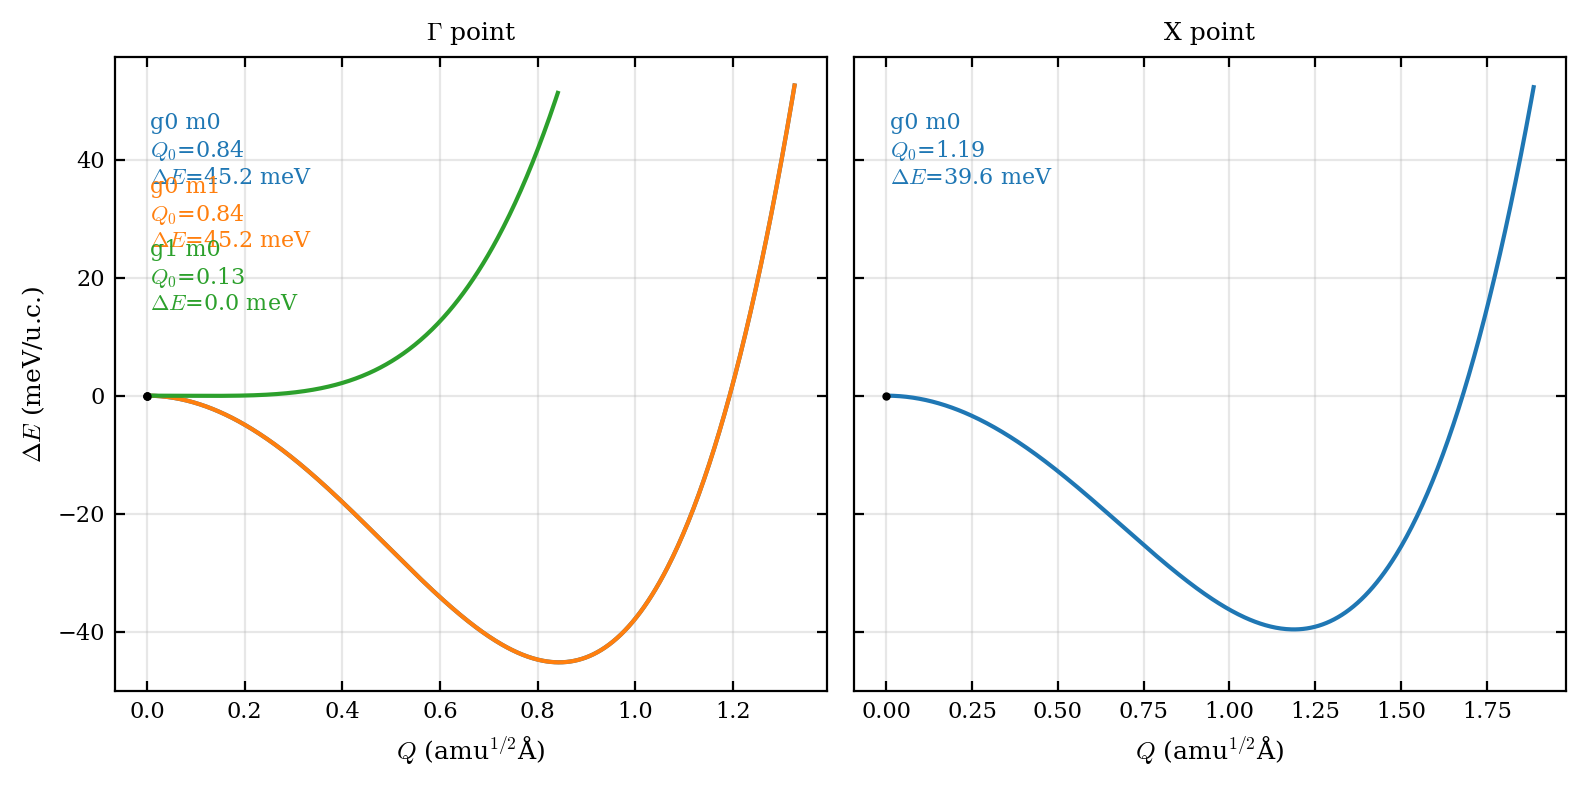

In [162]:
plot_frozen_phonons(results, mirror=False)

0


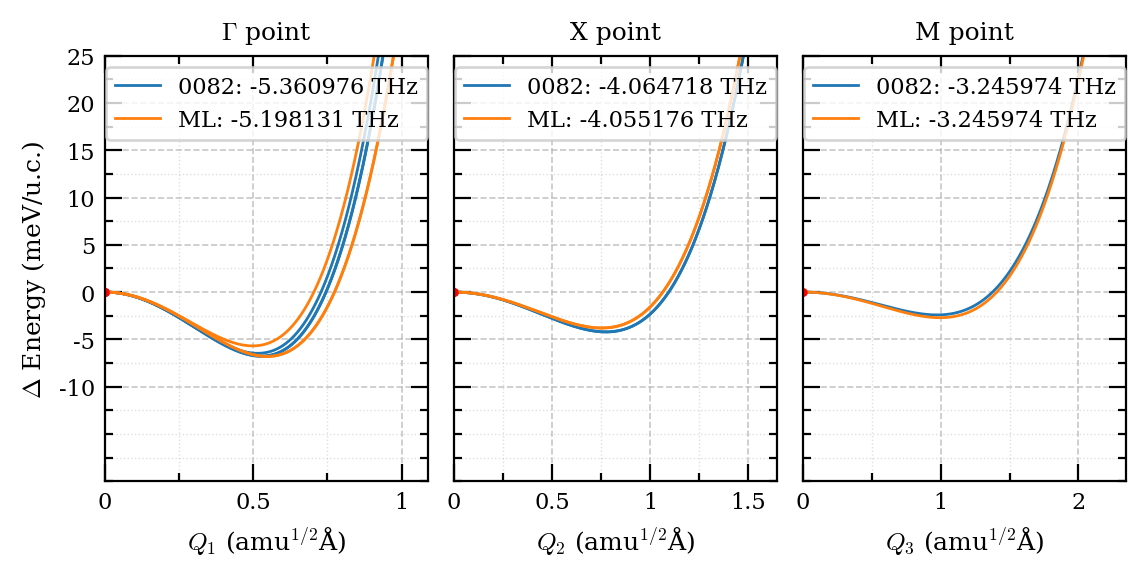

In [65]:
plotDWs('BaTiO3', ['0082', 'ML'])